In [34]:
## This version of 1D greedy algorithm, the numerical quadrature used for assembling the linear system is consistent with 
## the quadrature used for the argmax subproblem.
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
from scipy.sparse import linalg
from pathlib import Path
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

pi = torch.tensor(np.pi,dtype=torch.float64)
torch.set_default_dtype(torch.float64)

class model_special_cosine(nn.Module):
    """special double cosine activation function 
    \sum_{i} a_i cos( \pi cos( x + c_i) ) 
    """
    def __init__(self, input_size, hidden_size1, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1, bias = True)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
    def forward(self, x):
        u1 = self.fc2( torch.cos( 2 * pi *torch.cos( self.fc1(x)))) 
        return u1
    
class model_cosine(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1, bias = False)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
    def forward(self, x):
        u1 = self.fc2(torch.cos(2 * pi * self.fc1(x)))
        return u1

In [35]:
def PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order):
    """ Output the coeffients and weights for piecewise Gauss Quadrature 
    Parameters
    ----------
    x_l : float 
    left endpoint of an interval 
    
    x_r: float
    right endpoint of an interval 
    
    integration_intervals: int
    number of subintervals for integration
    
    Returns
    -------
    coef1_expand
    
    gw_expand
    
    integration_points
    """
    x,w = np.polynomial.legendre.leggauss(order)
    gx = torch.tensor(x).to(device)
    gx = gx.view(1,-1) # row vector 
    gw = torch.tensor(w).to(device)    
    gw = gw.view(-1,1) # Column vector 
    nodes = torch.linspace(x_l,x_r,Nx+1).view(-1,1).to(device) 
    coef1 = ((nodes[1:,:] - nodes[:-1,:])/2) # n by 1  
    coef2 = ((nodes[1:,:] + nodes[:-1,:])/2) # n by 1  
    coef2_expand = coef2.expand(-1,gx.size(1)) # Expand to n by p shape, -1: keep the first dimension n , expand the 2nd dim (columns)
    integration_points = coef1@gx + coef2_expand
    integration_points = integration_points.flatten().view(-1,1) # Make it a column vector
    gw_expand = torch.tile(gw,(Nx,1)) # rows: n copies of current tensor, columns: 1 copy, no change
    # Modify coef1 to be compatible with func_values
    coef1_expand = coef1.expand(coef1.size(0),gx.size(1))    
    coef1_expand = coef1_expand.flatten().view(-1,1)

    return coef1_expand.to(device)*gw_expand.to(device), integration_points.to(device)


def PiecewiseGQ2D_weights_points(Nx, order,l_point = (-1,-1), r_point = (1,1)): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters. 
    Only works for the square domain centered at origin or with the left point at origin.
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    l_point: (x1,x2)
        left bottom point of the rectangular domain 
    r_point: (x1,x2)
        right top point of the rectangular domain 

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
    assert Nx%2==0, "Nx should be even" 

    h1 = (r_point[0] - l_point[0])/Nx
    h2 = (r_point[1] - l_point[1])/Nx 

    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * (h1/2) * (h2/2) # scale the weights  
    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h1/2 
    integration_points = scale_factor * integration_points

    offset = 0 if l_point[0] == 0 else 1 

    index = np.arange(1,Nx+1)- (Nx/2)*offset - 0.5 
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T
    ordered_pairs = torch.tensor(ordered_pairs)
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    ordered_pairs =  ordered_pairs.reshape(-1,2)

    translation = ordered_pairs*h1
    integration_points = integration_points + translation 
    return long_weights, integration_points

def PiecewiseGQ3D_weights_points(Nx, order,l_point = (-1,-1,-1), r_point = (1,1,1)): 

    """
    uniform grid, same grid size in each direction 
    """
    assert Nx%2==0, "Nx should be even" 
    # print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,x,indexing='ij')).reshape(3,-1).T
    weight_list = np.array(np.meshgrid(w,w,w,indexing='ij'))
    weights =   (weight_list[0]*weight_list[1]*weight_list[2]).ravel() 

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    h = (r_point[0] - l_point[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**3,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**3 /8 

    integration_points = torch.tile(gauss_pts,(Nx**3,1))
    # print("shape of integration_points", integration_points.size())
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    offset = 0 if l_point[0] == 0 else 1 
    index = np.arange(1,Nx+1)- (Nx/2)*offset - 0.5 
    # index = np.arange(1,Nx+1)-0.5
    ordered_pairs = np.array(np.meshgrid(index,index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(3,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**3)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,3)
    # print(ordered_pairs)
    translation = ordered_pairs*h 
    # print(translation)

    integration_points = integration_points + translation 

    return long_weights, integration_points


def minimize_linear_layer(model,target,solver="direct",Nx = 1024, order = 5):
    """
    calls the following functions (dependency): 
    1. compute_integration_nodes_relunn
    2. GQ_piecewise
    3. loss_function
    4. rhs_loss
    input: the nn model containing parameter 
    1. define the loss function  
    2. take derivative to extract the linear system A
    3. call the cg solver in scipy to solve the linear system 
    output: sol. solution of Ax = b
    """
    def loss_function_inside(x):
        #my_model is a global variable
        return 0.5*torch.pow(model(x)-target(x),2).to(device)

    def rhs_loss_inside(x): 
        # Helper function: differentiate this wrt linear layer parameters give the rhs
        return model(x)*target(x)
    
    # loss = GQ_piecewise(gw,gx,node,loss_function_inside) #loss_function
    weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 
    loss = weights.t() @ loss_function_inside(integration_points) 
    # loss = PiecewiseGQ1D(-1,1,loss_function_inside,Nx,order=order) #loss_function 

    # Extract the linear system A :  
    du1 = torch.autograd.grad(outputs=loss, inputs=model.fc2.weight, retain_graph=True,create_graph = True)[0]
    # jac = '' # Fix a bug: my_model -> model 2023 Mar. 14th 
    torch.set_printoptions(precision=8)
    # neuron_number = model.fc1.bias.size(0)
    neuron_number = model.fc1.weight.size(0) 
    # for i in range(neuron_number): # Fix a bug: hidden_size1 -> neuron_number 2023 Mar. 14th 
    #     duui = torch.autograd.grad(outputs=du1[0,i], inputs=model.fc2.weight, retain_graph=True)[0]
    #     if i == 0: # Fix a bug: my_model -> model 2023 Mar. 14th 
    #         jac = duui
    #     else: 
    #         jac = torch.cat([jac,duui],dim=0)
    jac = torch.cat([torch.autograd.grad(outputs=du1[0,i], inputs=model.fc2.weight, retain_graph=True)[0] for i in range(neuron_number)],dim=0)
    loss_helper = weights.t() @ rhs_loss_inside(integration_points) 
    # loss_helper = PiecewiseGQ1D(-pi,pi,rhs_loss_inside,Nx,order=order) 

    rhs = torch.autograd.grad(outputs=loss_helper, inputs=model.fc2.weight, retain_graph=True,create_graph = True)[0]
    rhs = rhs.view(-1,1)

    # Solve the linear system using CG
    # print("using: ",solver, end = " ")
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    return sol 


def minimize_linear_layer_explicit_assemble(model,target,weights, integration_points,solver="direct",activation = 'special_cosine'):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    # Nx = 1024
    # order = 5
    # weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 

    # start_time = time.time()
    if activation == 'special_cosine': 
        basis_value_col =  torch.cos( 2 * pi* torch.cos( model.fc1(integration_points)) )  # activation function dependent
    elif activation == 'cosine':
        basis_value_col =  torch.cos( 2 * pi* model.fc1(integration_points) )  
    weighted_basis_value_col = basis_value_col * weights
    jac = weighted_basis_value_col.t() @ basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs = weighted_basis_value_col.t() @ target(integration_points) 

    # print("using: ",solver, end = " ")
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    return sol 

def plot_solution_modified(r1,r2,model,x_test,u_true,name=None): 
    # Plot function: test results 
    u_model_cpu = model(x_test).cpu().detach()
    
    w = model.fc1.weight.data.squeeze()
    b = model.fc1.bias.data.squeeze()
    x_model_pt = (-b/w).view(-1,1)
    u_model_pt = model(x_model_pt).cpu().detach()
    plt.figure(dpi = 100)
    plt.plot(x_test.cpu(),u_model_cpu,'-.',label = "nn function")
    plt.plot(x_test.cpu(),u_true.cpu(),label = "true")
#     plt.plot(x_model_pt,u_model_pt,'.r')
    if name!=None: 
        plt.title(name)
    plt.legend()
    plt.show()

def initialize_uniform(my_model,target = None):
    """
    mutator function. input: my_model
    """
    #FEM initialization
    neuron_number = my_model.fc1.bias.size(0)
    h = 2*1/neuron_number
    #wi(x-x_i)
    wi = torch.full((neuron_number,1),1/h)
    bi = torch.linspace(-1,1,neuron_number + 1)[:-1].view(neuron_number,1) #x_i
    bi = -(wi*bi).view(neuron_number)
    my_model.fc1.weight.data = wi # somehow this local variable is not destroyed
    my_model.fc1.bias.data = bi
    return my_model 
    
def initialize_w_b_uniform(my_model,R_m):
    nn.init.uniform_(my_model.fc1.weight, a = -R_m, b = R_m)
    # nn.init.uniform_(my_model.fc1.bias, a = -R_m, b = R_m)
    return my_model 

def initialize_normal(my_model, mu, sigma):
    nn.init.normal_(my_model.fc1.weight, mean = mu, std = sigma)
    return my_model

def set_linear_layer_to_fixed_weights(my_model):
    neuron_num = my_model.fc1.weight.size(0)
    coefs = torch.ones(neuron_num) * 1/neuron_num 
    my_model.fc2.weight.data[0,:] = coefs[:]  
    return my_model

def plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title): 

    plt.figure(dpi = 400) 
    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1) 

    # Taking the logarithm of both M and errors
    log_M = np.log(neuron_num_arr) 
    log_errors = np.log(mean_err_l2_arr)
    # Perform linear regression to find the slope and intercept of the line
    slope, intercept = np.polyfit(log_M, log_errors, 1)
    # Create a function for the line of best fit

    def line_of_best_fit(x):
        return np.exp(intercept) * (x ** slope)
    best_fit = line_of_best_fit(neuron_num_arr) 

    plt.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ))
    plt.yscale('log') 
    plt.xscale('log') 
    plt.legend() 
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title) 
    plt.show() 

### test quadrature method 

## 1D Monte-Carlo sampling 

In [7]:
def target(x): 
    return torch.exp(-pi*x**2) # +  0.2 * torch.sin(4 * pi * x) 

err_l2_list = [] 
for n in range(1,10000,100): 

    my_model = model_cosine(1, n, 1).to(device) 
    my_model = set_linear_layer_to_fixed_weights(my_model) 
    mu = 0 
    sigma = (0.5/pi)**0.5
    my_model = initialize_normal(my_model,mu,sigma) 

    x_coord = torch.linspace(-1,1,1000).reshape(-1,1).to(device) 
    nn_func_values = my_model(x_coord).detach()
    target_values = target(x_coord) 

    # plt.plot(x_coord,nn_func_values, label = 'nn approximation')
    # plt.plot(x_coord,target_values, label = 'target')  
    # plt.legend() 
    # plt.show() 

    err_l2 = torch.sqrt(2 * torch.mean((nn_func_values - target_values)**2)) 
    print("L2 error: ",err_l2) 
    err_l2_list.append(err_l2) 


L2 error:  tensor(0.8525)
L2 error:  tensor(0.0756)
L2 error:  tensor(0.0505)
L2 error:  tensor(0.0202)
L2 error:  tensor(0.0073)
L2 error:  tensor(0.0460)
L2 error:  tensor(0.0083)
L2 error:  tensor(0.0101)
L2 error:  tensor(0.0220)
L2 error:  tensor(0.0182)
L2 error:  tensor(0.0080)
L2 error:  tensor(0.0105)
L2 error:  tensor(0.0289)
L2 error:  tensor(0.0102)
L2 error:  tensor(0.0044)
L2 error:  tensor(0.0273)
L2 error:  tensor(0.0286)
L2 error:  tensor(0.0440)
L2 error:  tensor(0.0126)
L2 error:  tensor(0.0120)
L2 error:  tensor(0.0138)
L2 error:  tensor(0.0192)
L2 error:  tensor(0.0139)
L2 error:  tensor(0.0077)
L2 error:  tensor(0.0105)
L2 error:  tensor(0.0084)
L2 error:  tensor(0.0113)
L2 error:  tensor(0.0116)
L2 error:  tensor(0.0045)
L2 error:  tensor(0.0023)
L2 error:  tensor(0.0098)
L2 error:  tensor(0.0135)
L2 error:  tensor(0.0149)
L2 error:  tensor(0.0061)
L2 error:  tensor(0.0106)
L2 error:  tensor(0.0214)
L2 error:  tensor(0.0324)
L2 error:  tensor(0.0090)
L2 error:  t

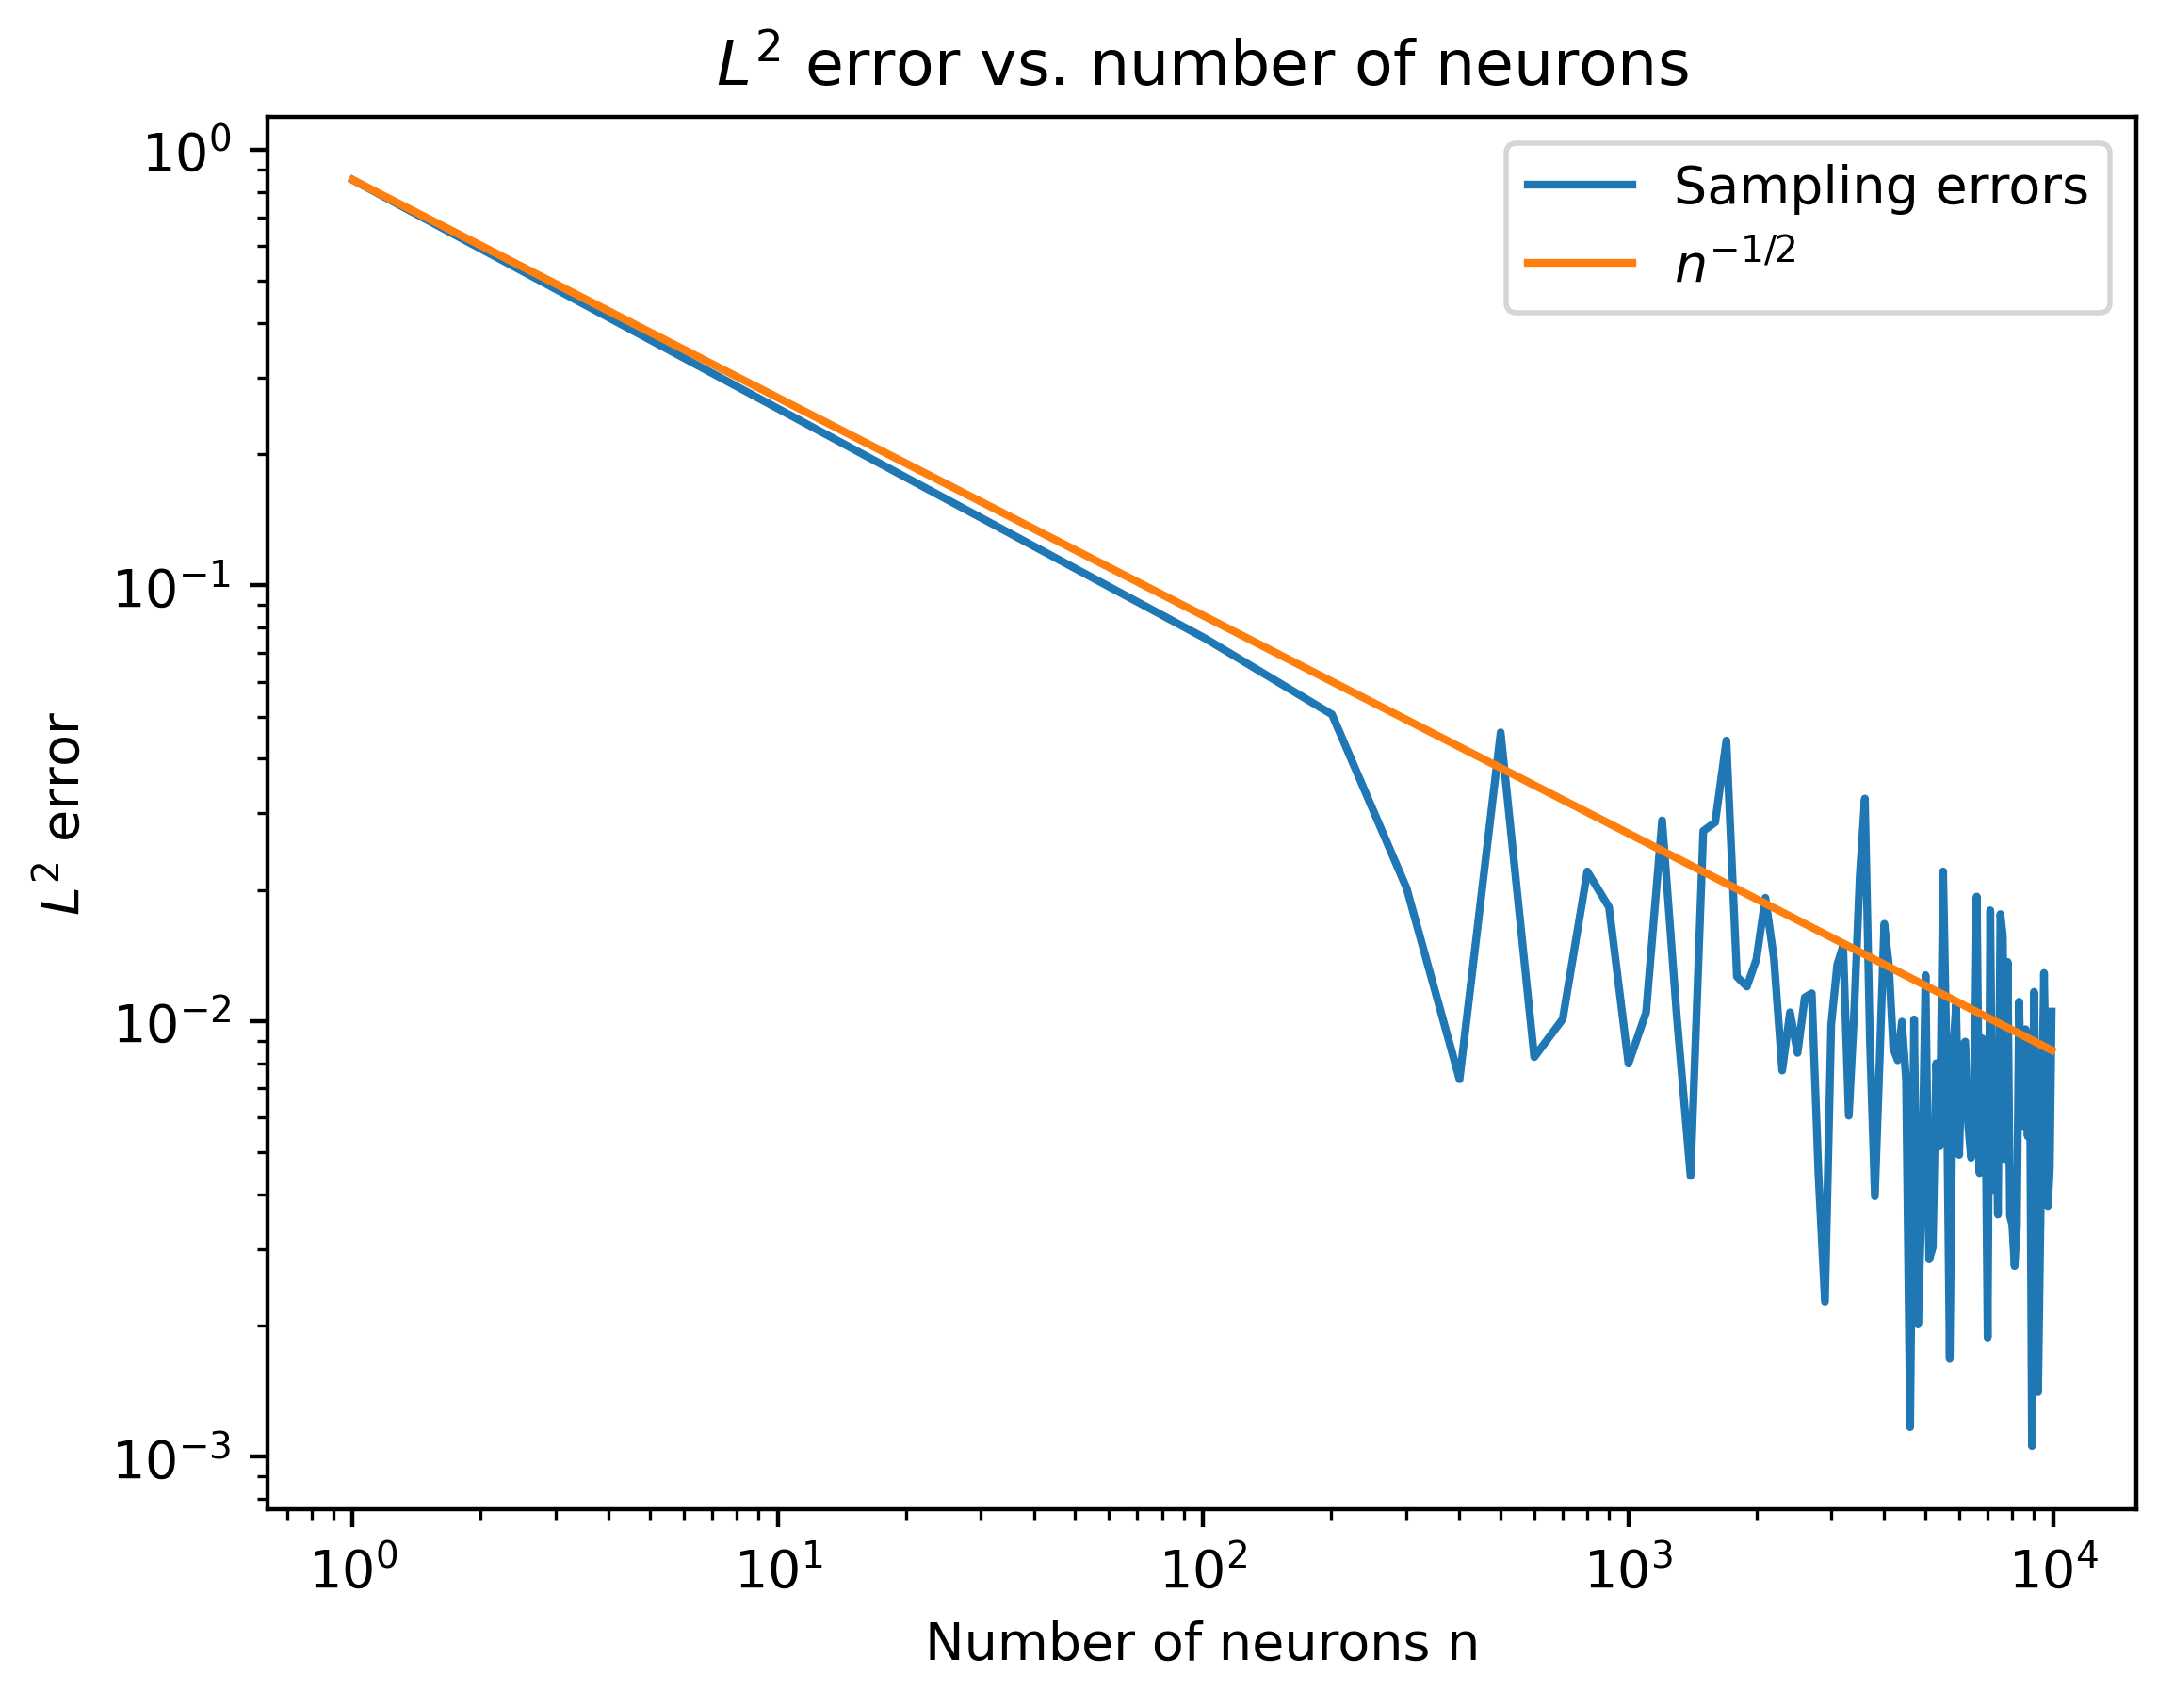

In [10]:
plt.figure(dpi = 400)
plt.plot(range(1,10000,100), err_l2_list, label = "Sampling errors") 
ref_line = err_l2_list[0] * torch.tensor([1/(n**0.5) for n in range(1,10000,100)])
plt.plot(range(1,10000,100),ref_line, label = "$n^{-1/2}$") 
plt.yscale('log') 
plt.xscale('log') 
plt.ylabel("$L^2$ error") 
plt.xlabel("Number of neurons n") 
plt.title("$L^2$ error vs. number of neurons") 
plt.legend() 
plt.show() 

## 1D RFM with Gaussian distribution, cosine activation 

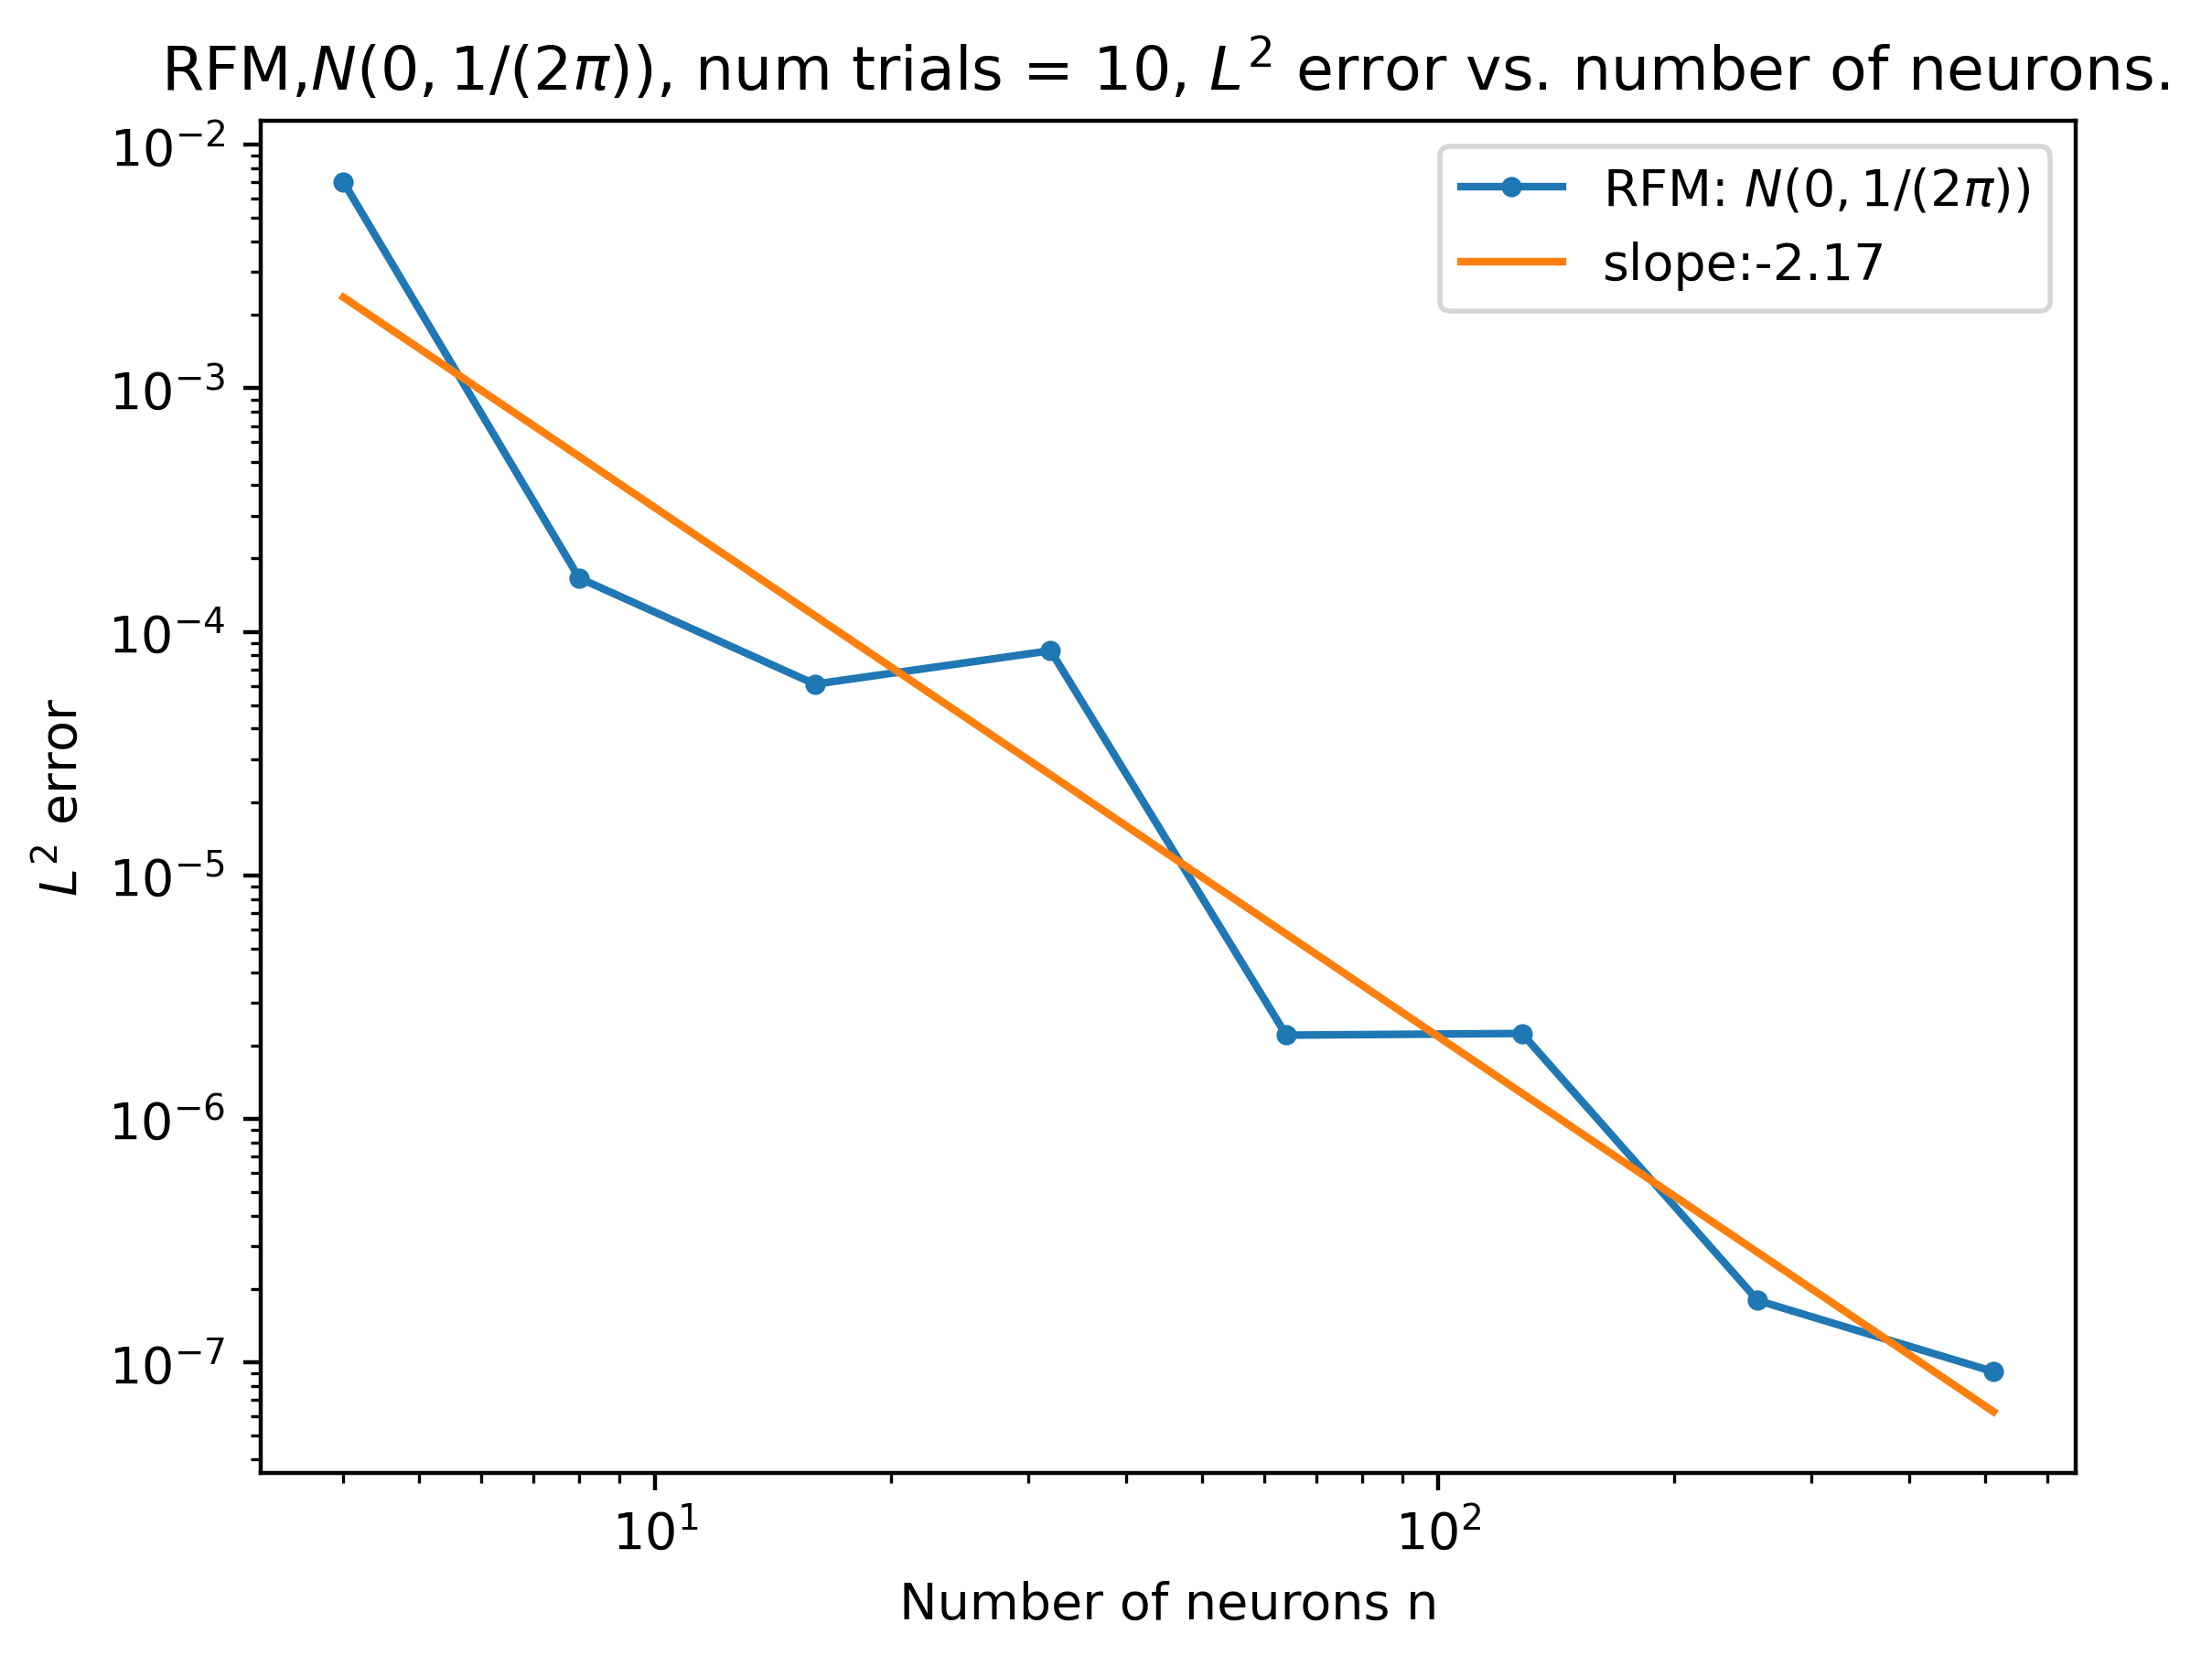

In [12]:
def target(x): 
    return torch.exp(-pi*x**2) # +  0.2 * torch.sin(4 * pi * x) 

weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx = 1024, order = 3)
mean_err_l2_list = [] 
exponent = 9  
exponent_list = [i for i in range(2,exponent+1)]
neuron_num_list = [2**i for i in exponent_list]
for n in neuron_num_list : 
    trial_num = 10 # 40 
    err_l2_trial = torch.zeros(trial_num) 
    for trial in range(trial_num):
        my_model = model_cosine(1, n, 1).to(device) 
        # my_model = set_linear_layer_to_fixed_weights(my_model) 
        mu = 0 
        sigma = 1 * (0.5/pi)**0.5
        my_model = initialize_normal(my_model,mu,sigma) 
        sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='cosine')
        my_model.fc2.weight.data[0,:] = sol[:]

        # x_coord = torch.linspace(-1,1,1000).reshape(-1,1).to(device) 
        with torch.no_grad():
            nn_func_values = my_model(integration_points)
        target_values = target(integration_points) 

        # plt.plot(x_coord,nn_func_values, label = 'nn approximation')
        # plt.plot(x_coord,target_values, label = 'target')  
        # plt.legend() 
        # plt.show() 
        diff_sqrd = (nn_func_values - target_values)**2
        err_l2 = ( weights.t() @ diff_sqrd )**0.5 
        err_l2_trial[trial] = err_l2 
        # print("L2 error: ",err_l2) 
    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

neuron_num_arr = np.array(neuron_num_list) 
mean_err_l2_arr = np.array(mean_err_l2_list) 
legend1 = "RFM: $N(0,1/(2 \pi))$" 
title = "RFM,$N(0,1/(2 \pi))$, num trials = {}, $L^2$ error vs. number of neurons. ".format(trial_num)  
plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title)

## 1D RFM Uniform distribution, special cosine function 

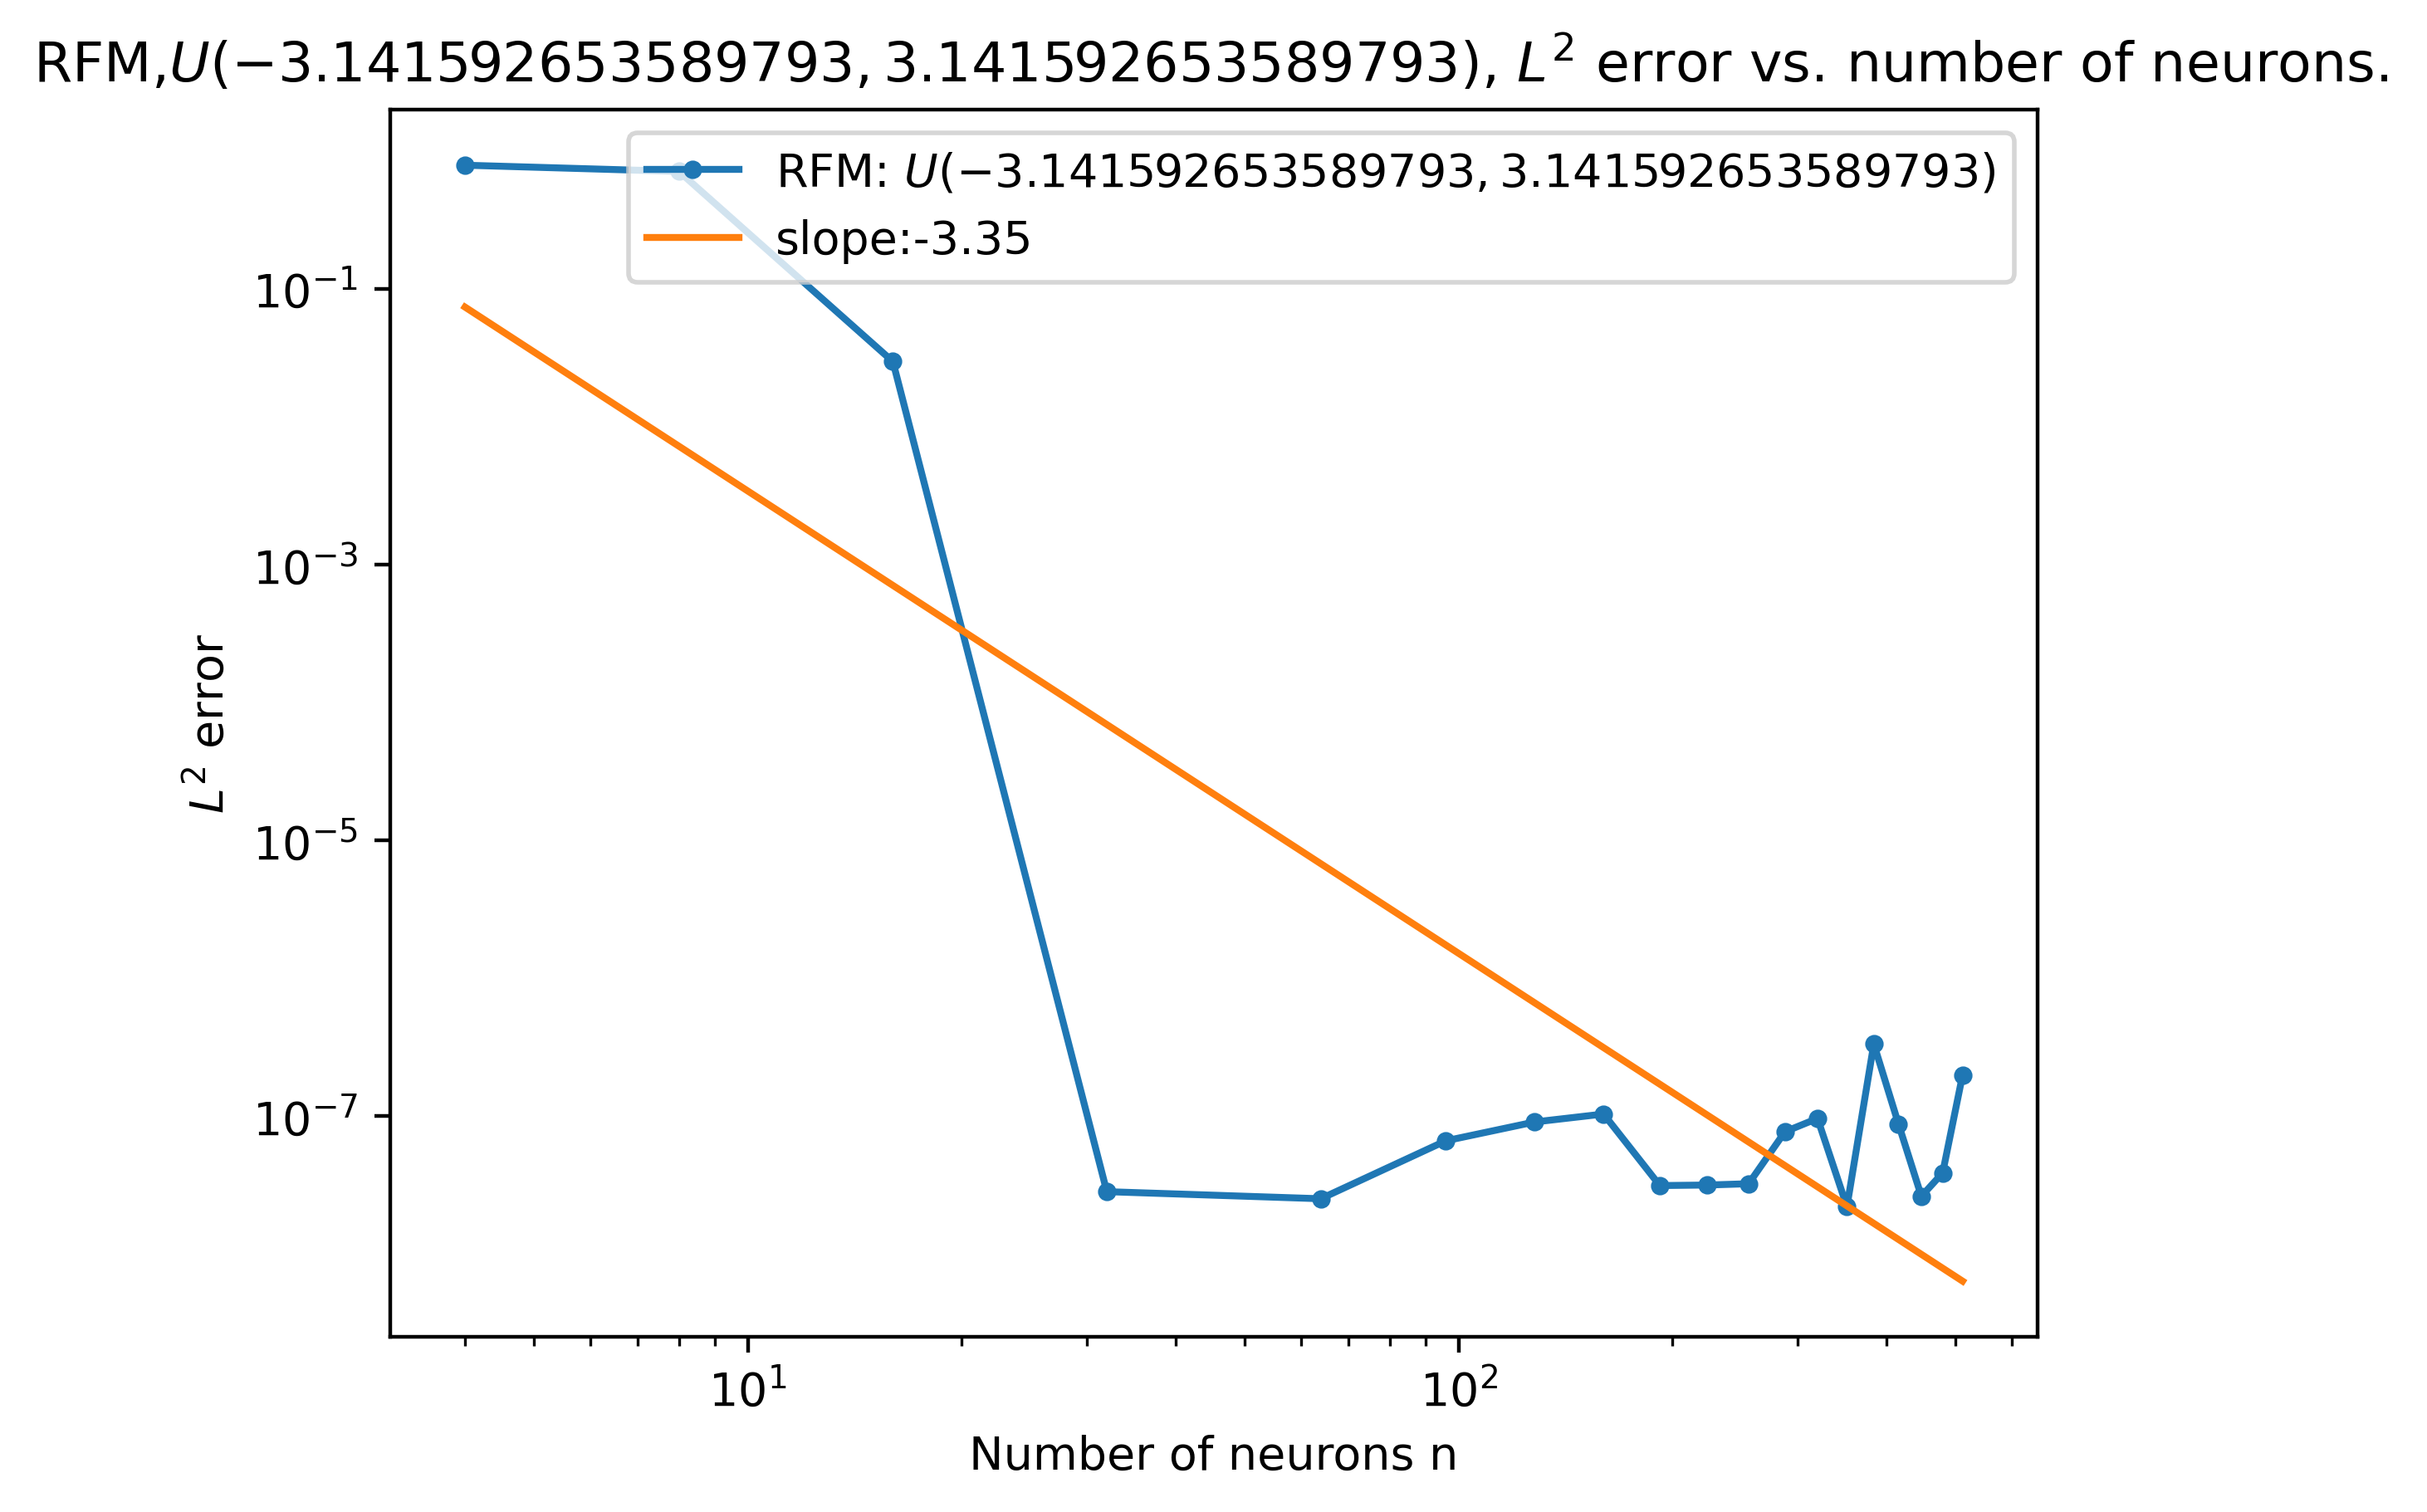

In [33]:
def target(x): 
    return torch.exp(-pi*x**2) # +  0.2 * torch.sin(4 * pi * x) 

weights, integration_points = PiecewiseGQ1D_weights_points(-pi,pi,Nx = 1024, order = 5)
save = False 
for R_m in [pi]: #  
    mean_err_l2_list = [] 
    exponent = 9 

    neuron_num_arr1 = np.array([2**i for i in range(2,6)]) 
    neuron_num_arr2 = np.arange(2**6, 512 +1, 32)
    neuron_num_arr = np.append(neuron_num_arr1,neuron_num_arr2) 

    for n in neuron_num_arr : 
        trial_num = 2   
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_cosine(1, n, 1).to(device) 
            # my_model = set_linear_layer_to_fixed_weights(my_model) 
            # mu = 0 
            # sigma = (0.5/pi)**0.5  
            my_model = initialize_w_b_uniform(my_model,R_m) 
            sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='cosine')
            my_model.fc2.weight.data[0,:] = sol[:]

            with torch.no_grad():
                nn_func_values = my_model(integration_points)
            target_values = target(integration_points) 

            diff_sqrd = (nn_func_values - target_values)**2
            err_l2 = ( weights.t() @ diff_sqrd )**0.5 
            err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("ave_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
    legend1 = "RFM: $U(-{}, {})$".format(R_m,R_m)
    title = "RFM,$U(-{}, {})$, $L^2$ error vs. number of neurons. ".format(R_m,R_m) 
    plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title) 

In [38]:



class model_special_cosine(nn.Module):
    """special double cosine activation function 
    \sum_{i} a_i cos( \pi cos( x + c_i) ) 
    """
    def __init__(self, input_size, hidden_size1, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1, bias = True)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
    def forward(self, x):
        u1 = self.fc2( torch.cos( pi *torch.cos( self.fc1(x)))) 
        return u1
    

def initialize_w_as_ones_b_uniform(my_model,R_m):
    nn.init.uniform_(my_model.fc1.bias, a = -R_m, b = R_m)
    nn.init.ones_(my_model.fc1.weight) 
    # nn.init.uniform_(my_model.fc1.bias, a = -R_m, b = R_m)
    return my_model 

my_model = model_special_cosine(1,10,1)
my_model = initialize_w_as_ones_b_uniform(my_model,pi) 
print(my_model.fc1.weight)
print(my_model.fc1.bias)


def minimize_linear_layer_explicit_assemble(model,target,weights, integration_points,solver="direct",activation = 'special_cosine'):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    # Nx = 1024
    # order = 5
    # weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 

    # start_time = time.time()
    if activation == 'special_cosine': 
        basis_value_col =  torch.cos(  pi* torch.cos( model.fc1(integration_points)) )  # activation function dependent
    elif activation == 'cosine':
        basis_value_col =  torch.cos( 2 * pi* model.fc1(integration_points) )  
    weighted_basis_value_col = basis_value_col * weights
    jac = weighted_basis_value_col.t() @ basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs = weighted_basis_value_col.t() @ target(integration_points) 

    # print("using: ",solver, end = " ")
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    return sol 


Parameter containing:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], requires_grad=True)
Parameter containing:
tensor([ 0.5960,  0.2263, -2.2730, -0.6516,  2.4550, -2.6908,  1.2252, -2.7897,
         2.4848,  0.6617], requires_grad=True)


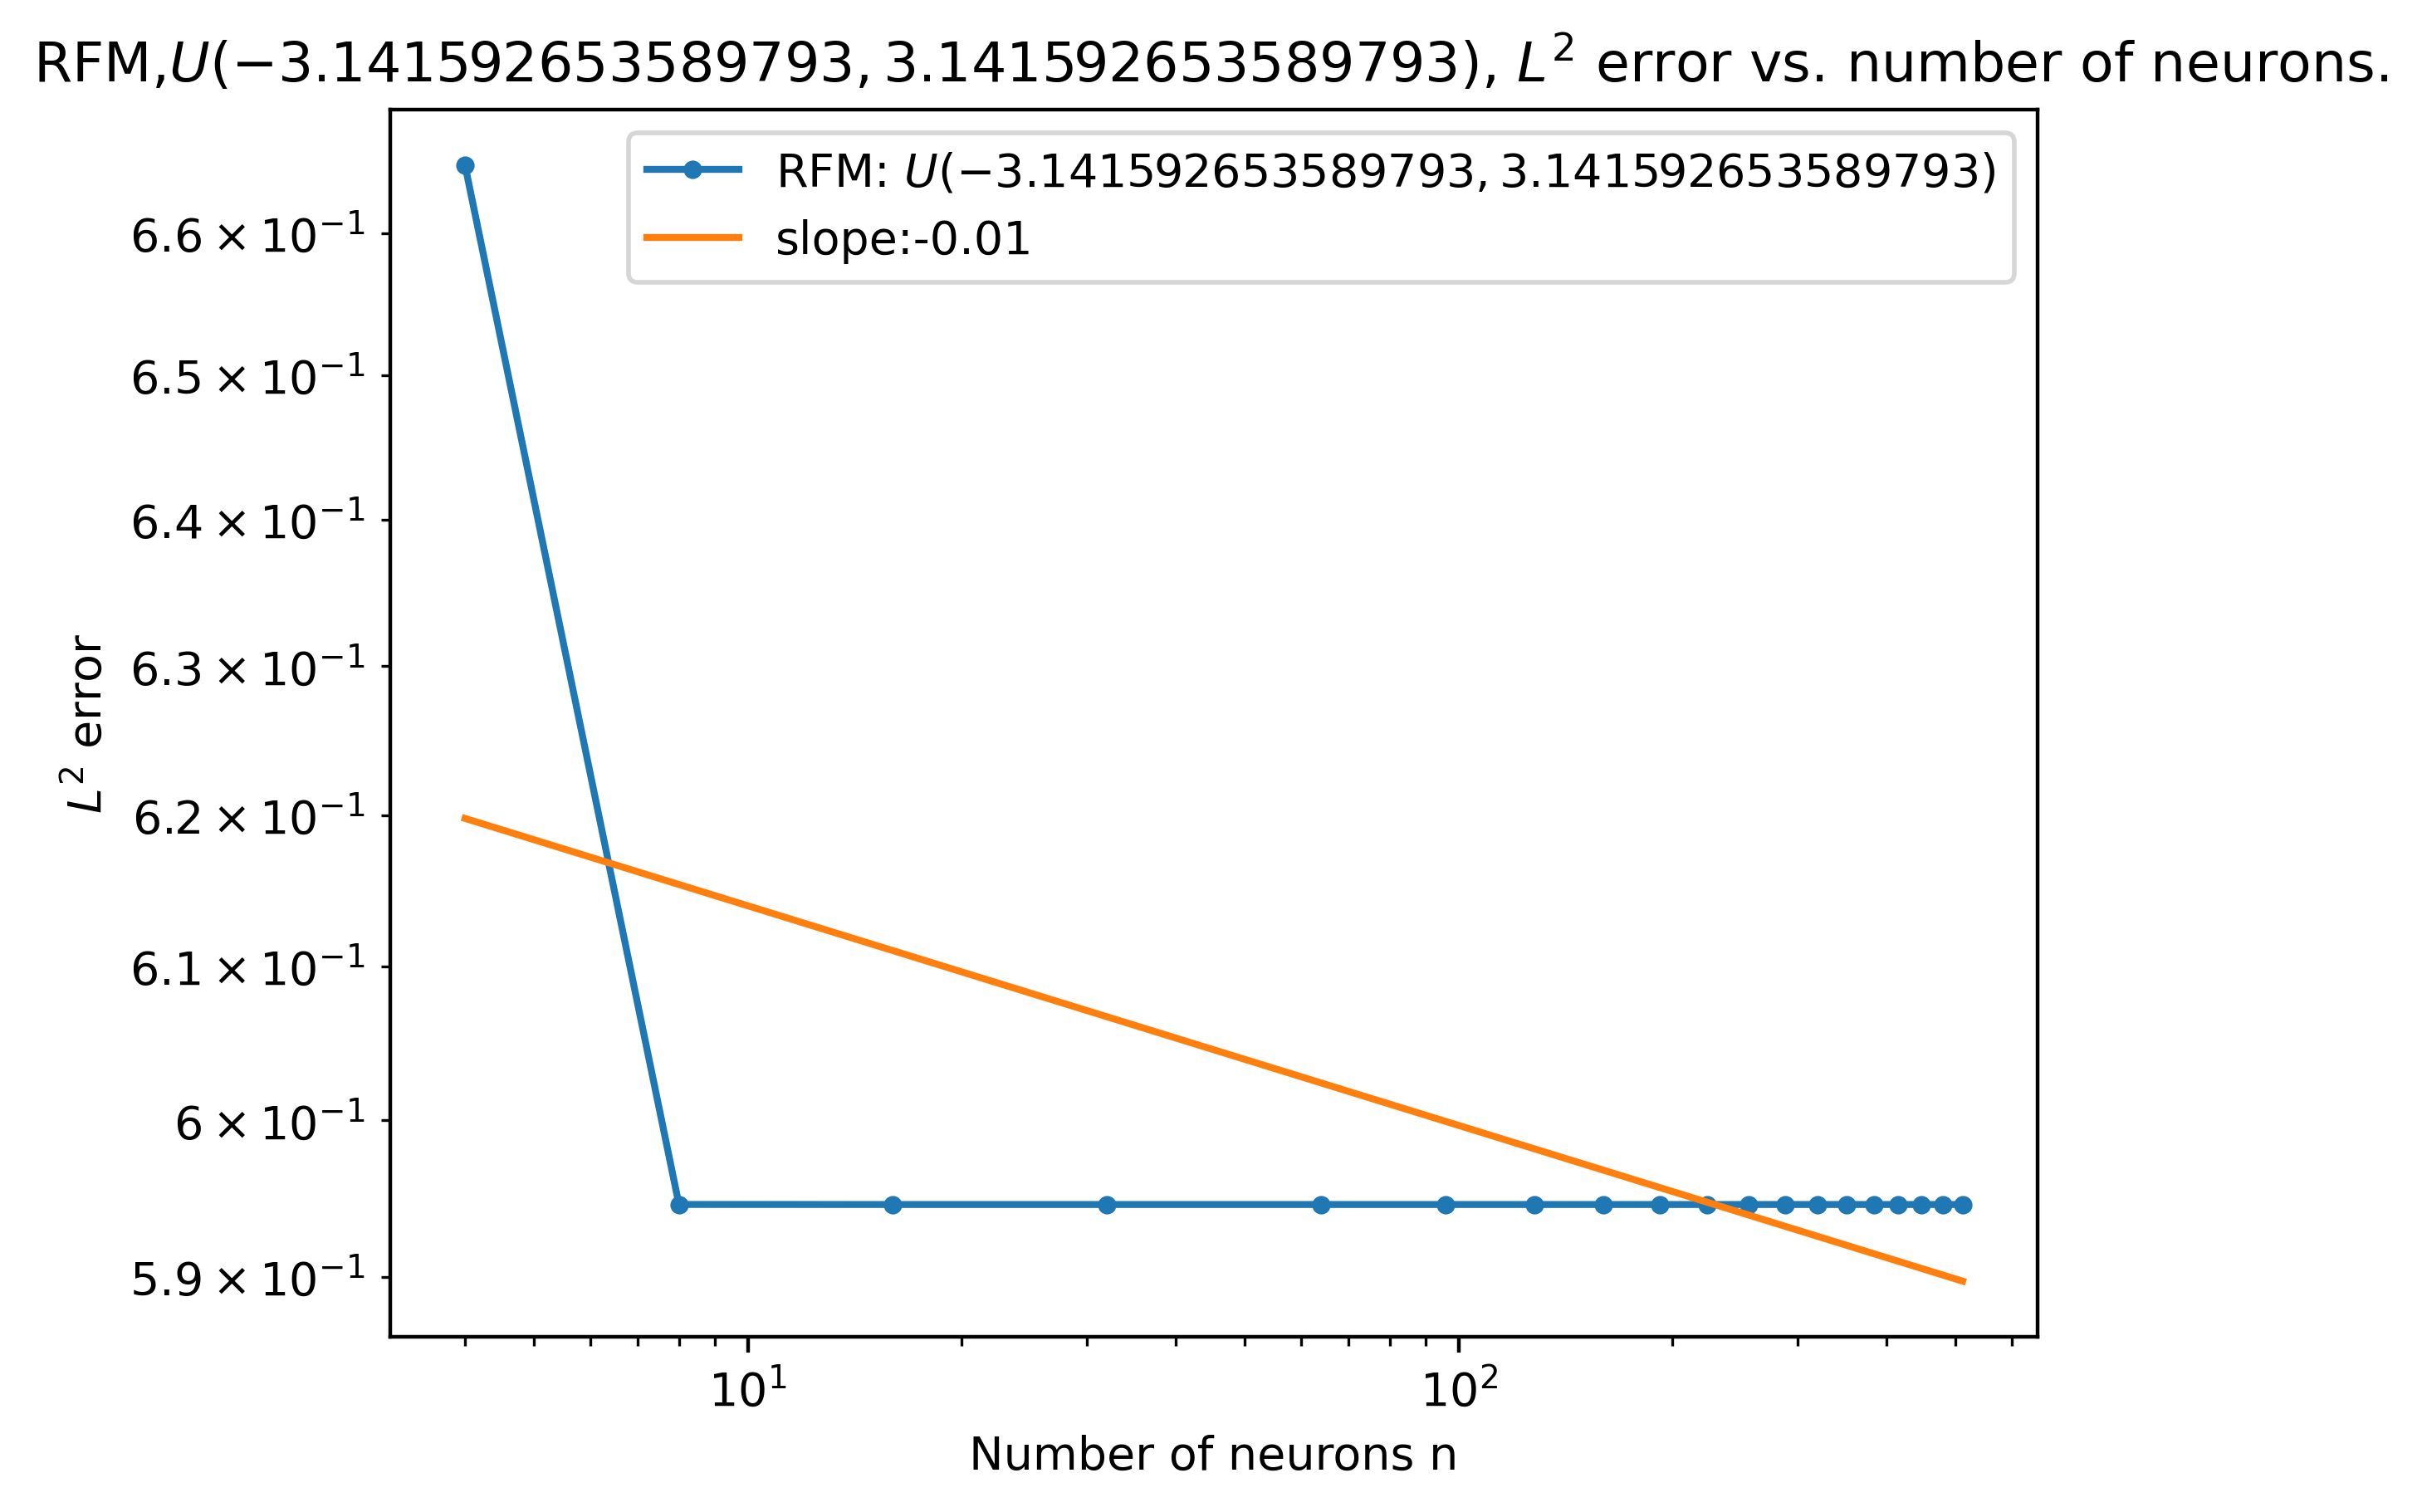

In [39]:
def target(x): 
    return torch.exp(-pi*x**2) # +  0.2 * torch.sin(4 * pi * x) 

weights, integration_points = PiecewiseGQ1D_weights_points(-pi,pi,Nx = 1024, order = 3)
save = False 
for R_m in [pi]: #  
    mean_err_l2_list = [] 
    exponent = 9 

    neuron_num_arr1 = np.array([2**i for i in range(2,6)]) 
    neuron_num_arr2 = np.arange(2**6, 512 +1, 32)
    neuron_num_arr = np.append(neuron_num_arr1,neuron_num_arr2) 

    for n in neuron_num_arr : 
        trial_num = 2   
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_special_cosine(1, n, 1).to(device) 
            # my_model = set_linear_layer_to_fixed_weights(my_model) 
            # mu = 0 
            # sigma = (0.5/pi)**0.5  
            my_model = initialize_w_as_ones_b_uniform(my_model,R_m) 
            sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='special_cosine')
            my_model.fc2.weight.data[0,:] = sol[:]

            with torch.no_grad():
                nn_func_values = my_model(integration_points)
            target_values = target(integration_points) 

            diff_sqrd = (nn_func_values - target_values)**2
            err_l2 = ( weights.t() @ diff_sqrd )**0.5 
            err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("ave_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
    legend1 = "RFM: $U(-{}, {})$".format(R_m,R_m)
    title = "RFM,$U(-{}, {})$, $L^2$ error vs. number of neurons. ".format(R_m,R_m) 
    plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title) 

## 2D Monte-Carlo sampling 


In [158]:
def target(x): 
    return torch.exp(-pi*torch.sum(x**2, dim = 1, keepdim = True) ) # +  0.2 * torch.sin(4 * pi * x) 

err_l2_list = [] 
neuron_arr = torch.arange(1,10000,100) 
for n in neuron_arr: 

    my_model = model_cosine(2, n, 1).to(device) 
    my_model = set_linear_layer_to_fixed_weights(my_model) 
    mu = 0 
    sigma = (0.5/pi)**0.5
    my_model = initialize_normal(my_model,mu,sigma) 

    # x_coord = torch.linspace(-1,1,1000).reshape(-1,1).to(device) 
    # nn_func_values = my_model(x_coord).detach()
    # target_values = target(x_coord) 

    # plt.plot(x_coord,nn_func_values, label = 'nn approximation')
    # plt.plot(x_coord,target_values, label = 'target')  
    # plt.legend() 
    # plt.show() 
    weights, integration_points = PiecewiseGQ2D_weights_points(50,3,l_point = (-1,-1), r_point = (1,1))
    with torch.no_grad():
        nn_func_values = my_model(integration_points) 
    target_values = target(integration_points) 
    diff_sqrd = (nn_func_values - target_values)**2 
    err_l2 = ( weights.t() @ diff_sqrd )**0.5 
    # err_l2 = torch.sqrt(2 * torch.mean((nn_func_values - target_values)**2)) 
    
    print("L2 error: ",err_l2) 
    err_l2_list.append(err_l2) 


L2 error:  tensor([[1.20483034]])
L2 error:  tensor([[0.13472664]])
L2 error:  tensor([[0.05938484]])
L2 error:  tensor([[0.05124949]])
L2 error:  tensor([[0.05516953]])
L2 error:  tensor([[0.04027437]])
L2 error:  tensor([[0.05231379]])
L2 error:  tensor([[0.05623863]])
L2 error:  tensor([[0.03932520]])
L2 error:  tensor([[0.06085374]])
L2 error:  tensor([[0.04527971]])
L2 error:  tensor([[0.02091260]])
L2 error:  tensor([[0.02923357]])
L2 error:  tensor([[0.03065916]])
L2 error:  tensor([[0.03886582]])
L2 error:  tensor([[0.01979157]])
L2 error:  tensor([[0.03219915]])
L2 error:  tensor([[0.01852161]])
L2 error:  tensor([[0.03575904]])
L2 error:  tensor([[0.03404007]])
L2 error:  tensor([[0.03279242]])
L2 error:  tensor([[0.02390170]])
L2 error:  tensor([[0.03354140]])
L2 error:  tensor([[0.02435252]])
L2 error:  tensor([[0.03202759]])
L2 error:  tensor([[0.01356918]])
L2 error:  tensor([[0.01610119]])
L2 error:  tensor([[0.02429628]])
L2 error:  tensor([[0.01786674]])
L2 error:  ten

In [164]:
neuron_arr = torch.arange(1,10000,100) 
for n in neuron_arr:
    print(n, end = '\t')

tensor(1)	tensor(101)	tensor(201)	tensor(301)	tensor(401)	tensor(501)	tensor(601)	tensor(701)	tensor(801)	tensor(901)	tensor(1001)	tensor(1101)	tensor(1201)	tensor(1301)	tensor(1401)	tensor(1501)	tensor(1601)	tensor(1701)	tensor(1801)	tensor(1901)	tensor(2001)	tensor(2101)	tensor(2201)	tensor(2301)	tensor(2401)	tensor(2501)	tensor(2601)	tensor(2701)	tensor(2801)	tensor(2901)	tensor(3001)	tensor(3101)	tensor(3201)	tensor(3301)	tensor(3401)	tensor(3501)	tensor(3601)	tensor(3701)	tensor(3801)	tensor(3901)	tensor(4001)	tensor(4101)	tensor(4201)	tensor(4301)	tensor(4401)	tensor(4501)	tensor(4601)	tensor(4701)	tensor(4801)	tensor(4901)	tensor(5001)	tensor(5101)	tensor(5201)	tensor(5301)	tensor(5401)	tensor(5501)	tensor(5601)	tensor(5701)	tensor(5801)	tensor(5901)	tensor(6001)	tensor(6101)	tensor(6201)	tensor(6301)	tensor(6401)	tensor(6501)	tensor(6601)	tensor(6701)	tensor(6801)	tensor(6901)	tensor(7001)	tensor(7101)	tensor(7201)	tensor(7301)	tensor(7401)	tensor(7501)	tensor(7601)	tensor(7701

/Applications/anaconda3/lib/python3.9/site-packages/numpy/core/shape_base.py:65: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  ary = asanyarray(ary)
/Applications/anaconda3/lib/python3.9/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


torch.Size([1, 100])
torch.Size([100])


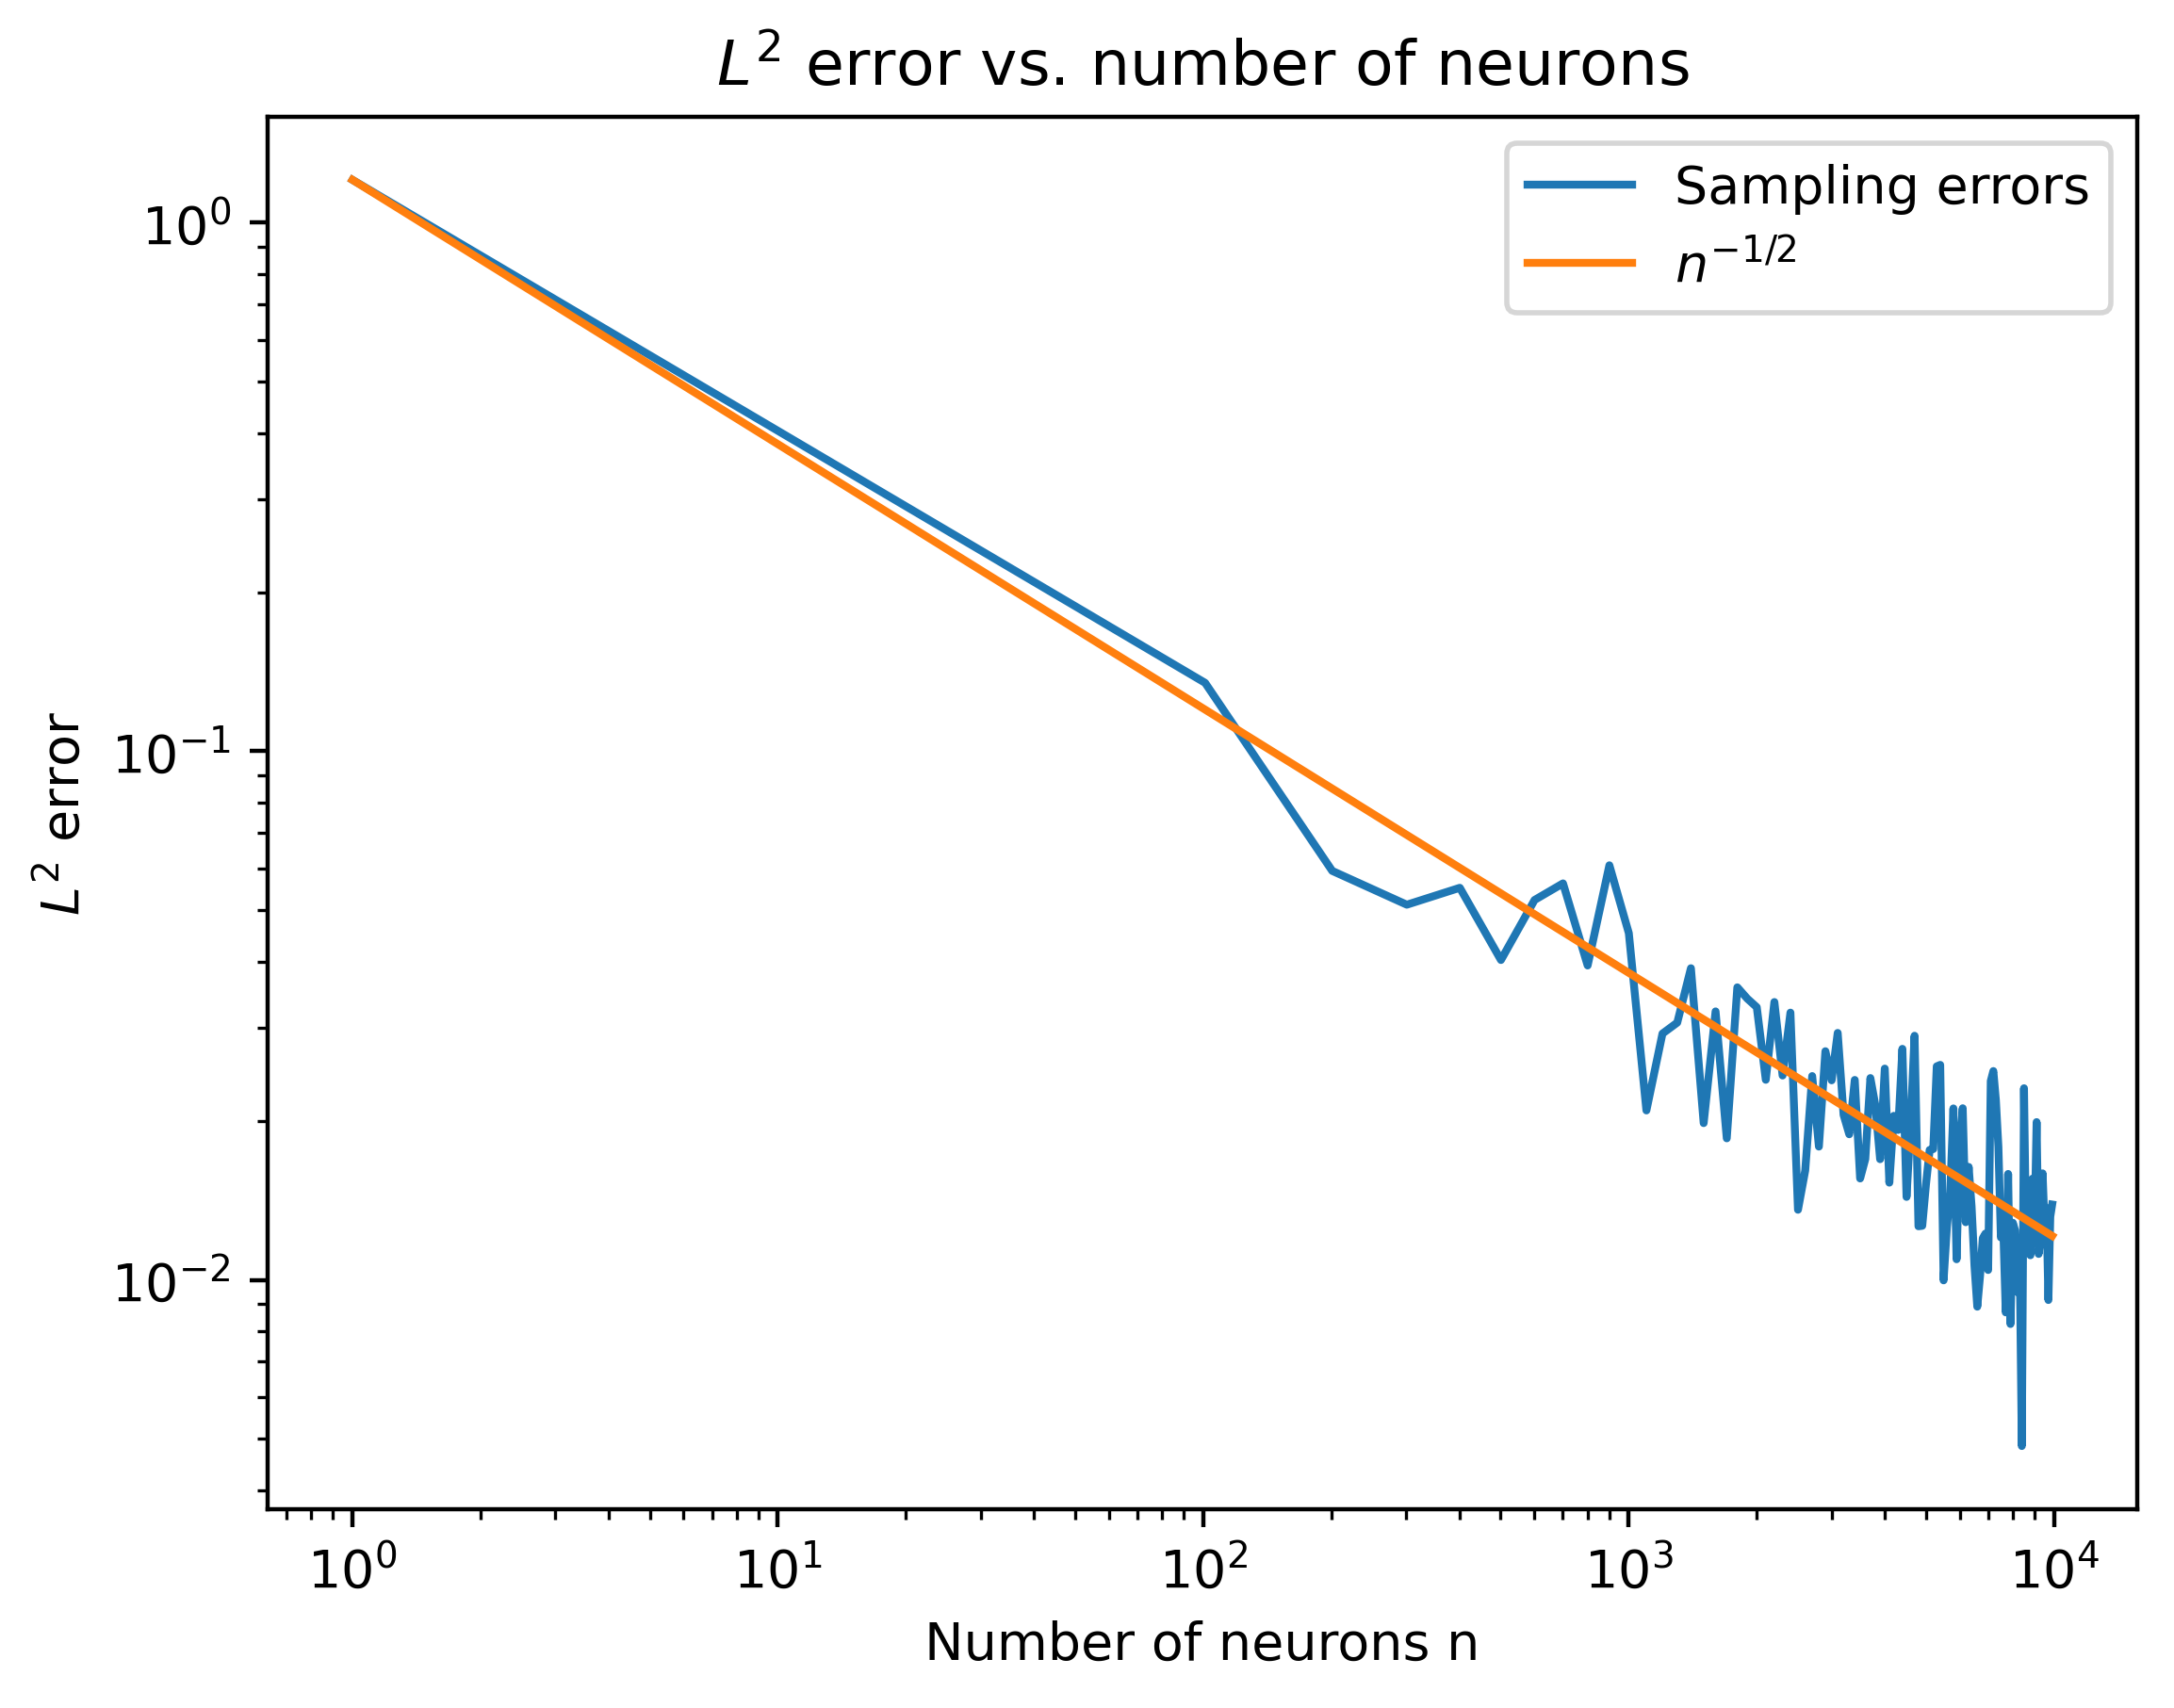

In [167]:
plt.figure(dpi = 400)
plt.plot(neuron_arr, err_l2_list, label = "Sampling errors") 
ref_line = err_l2_list[0] * torch.tensor([1/(n**0.5) for n in neuron_arr])

print(ref_line.size())
print(neuron_arr.size()) 

plt.plot(neuron_arr,ref_line.squeeze(), label = "$n^{-1/2}$") 
plt.yscale('log') 
plt.xscale('log') 
plt.ylabel("$L^2$ error") 
plt.xlabel("Number of neurons n") 
plt.title("$L^2$ error vs. number of neurons") 
plt.legend() 
plt.show() 

## 2D RFM - Normal distribution 

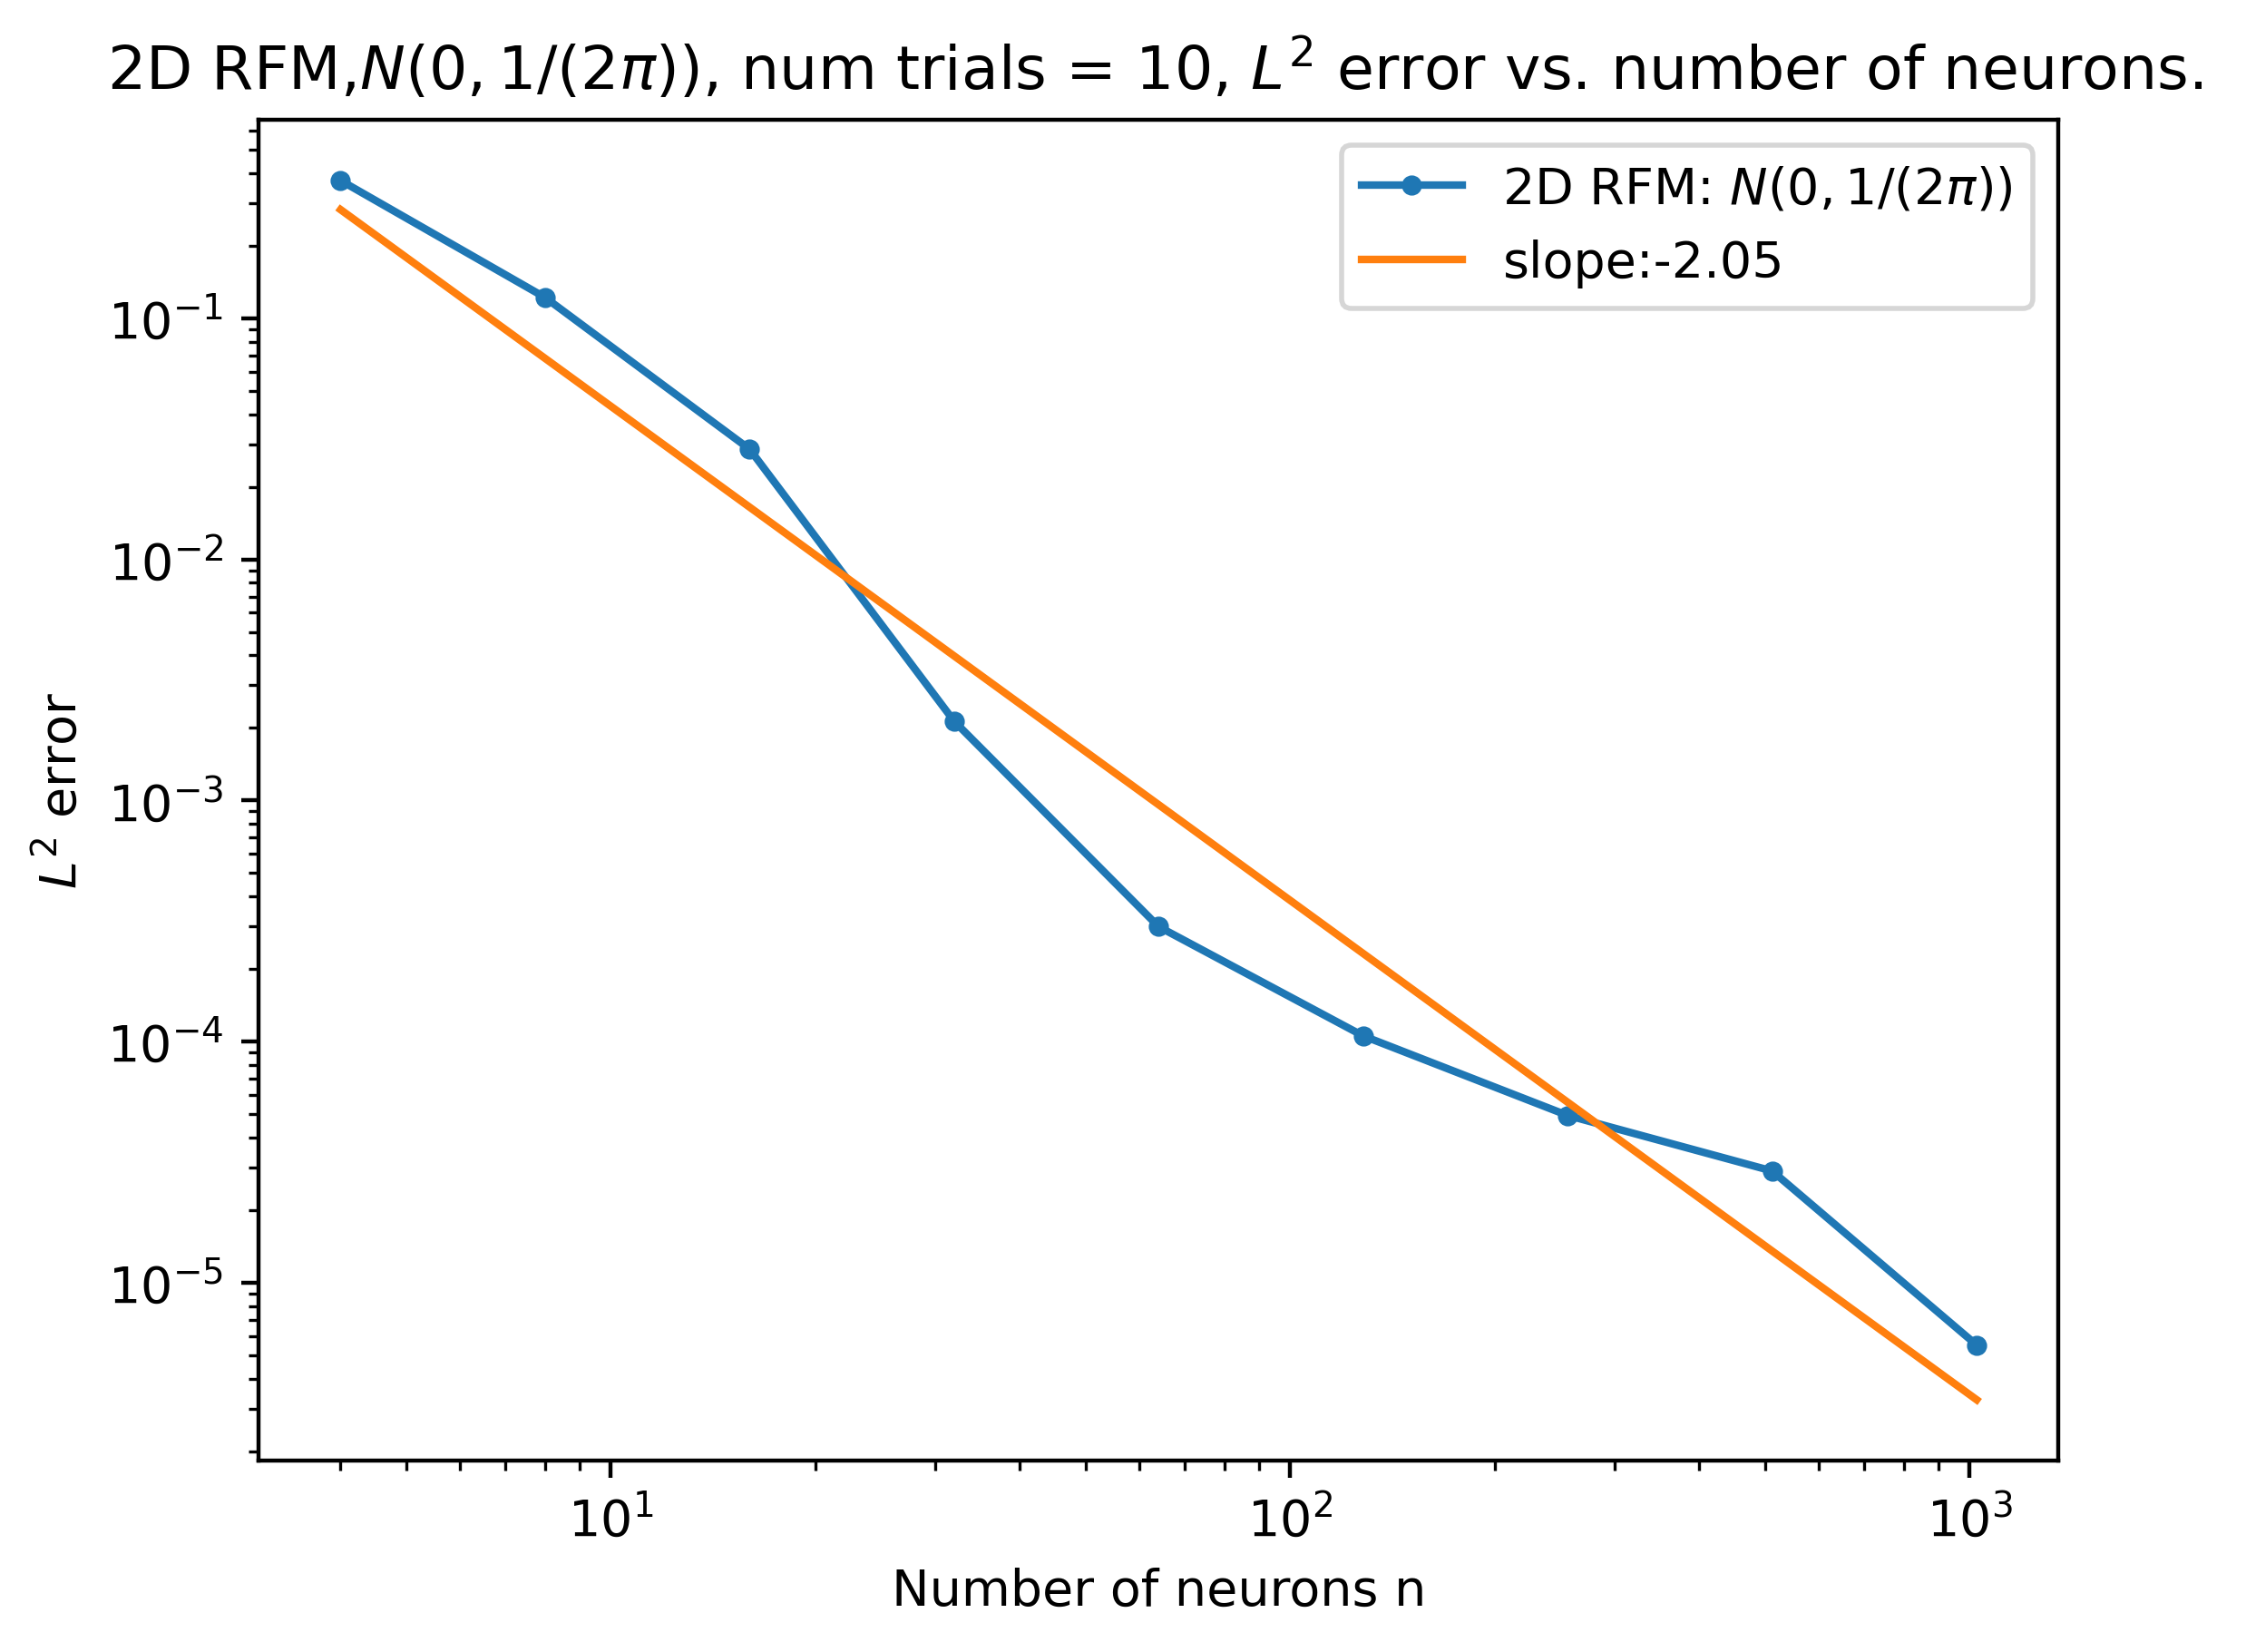

In [174]:
def target(x): 
    return torch.exp(-pi*torch.sum(x**2, dim = 1, keepdim = True) ) # +  0.2 * torch.sin(4 * pi * x) 

weights, integration_points = PiecewiseGQ2D_weights_points(Nx = 80, order = 3,l_point = (-1,-1), r_point = (1,1))
mean_err_l2_list = [] 
exponent = 10    
exponent_list = [i for i in range(2,exponent+1)]
neuron_num_list = [2**i for i in exponent_list]
for n in neuron_num_list : 
    trial_num = 10  # 40 
    err_l2_trial = torch.zeros(trial_num) 
    for trial in range(trial_num):
        my_model = model_cosine(2, n, 1).to(device) 
        # my_model = set_linear_layer_to_fixed_weights(my_model) 
        mu = 0 
        sigma = 1 * (0.5/pi)**0.5
        my_model = initialize_normal(my_model,mu,sigma) 
        sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct")
        my_model.fc2.weight.data[0,:] = sol[:]

        # x_coord = torch.linspace(-1,1,1000).reshape(-1,1).to(device) 
        with torch.no_grad():
            nn_func_values = my_model(integration_points)
        target_values = target(integration_points) 

        # plt.plot(x_coord,nn_func_values, label = 'nn approximation')
        # plt.plot(x_coord,target_values, label = 'target')  
        # plt.legend() 
        # plt.show() 
        diff_sqrd = (nn_func_values - target_values)**2
        err_l2 = ( weights.t() @ diff_sqrd )**0.5 
        err_l2_trial[trial] = err_l2 
        # print("L2 error: ",err_l2) 
    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

neuron_num_arr = np.array(neuron_num_list) 
mean_err_l2_arr = np.array(mean_err_l2_list) 
legend1 = "2D RFM: $N(0,1/(2 \pi))$" 
title = "2D RFM,$N(0,1/(2 \pi))$, num trials = {}, $L^2$ error vs. number of neurons. ".format(trial_num)  
plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title)

## 2D RFM - Uniform distribution 

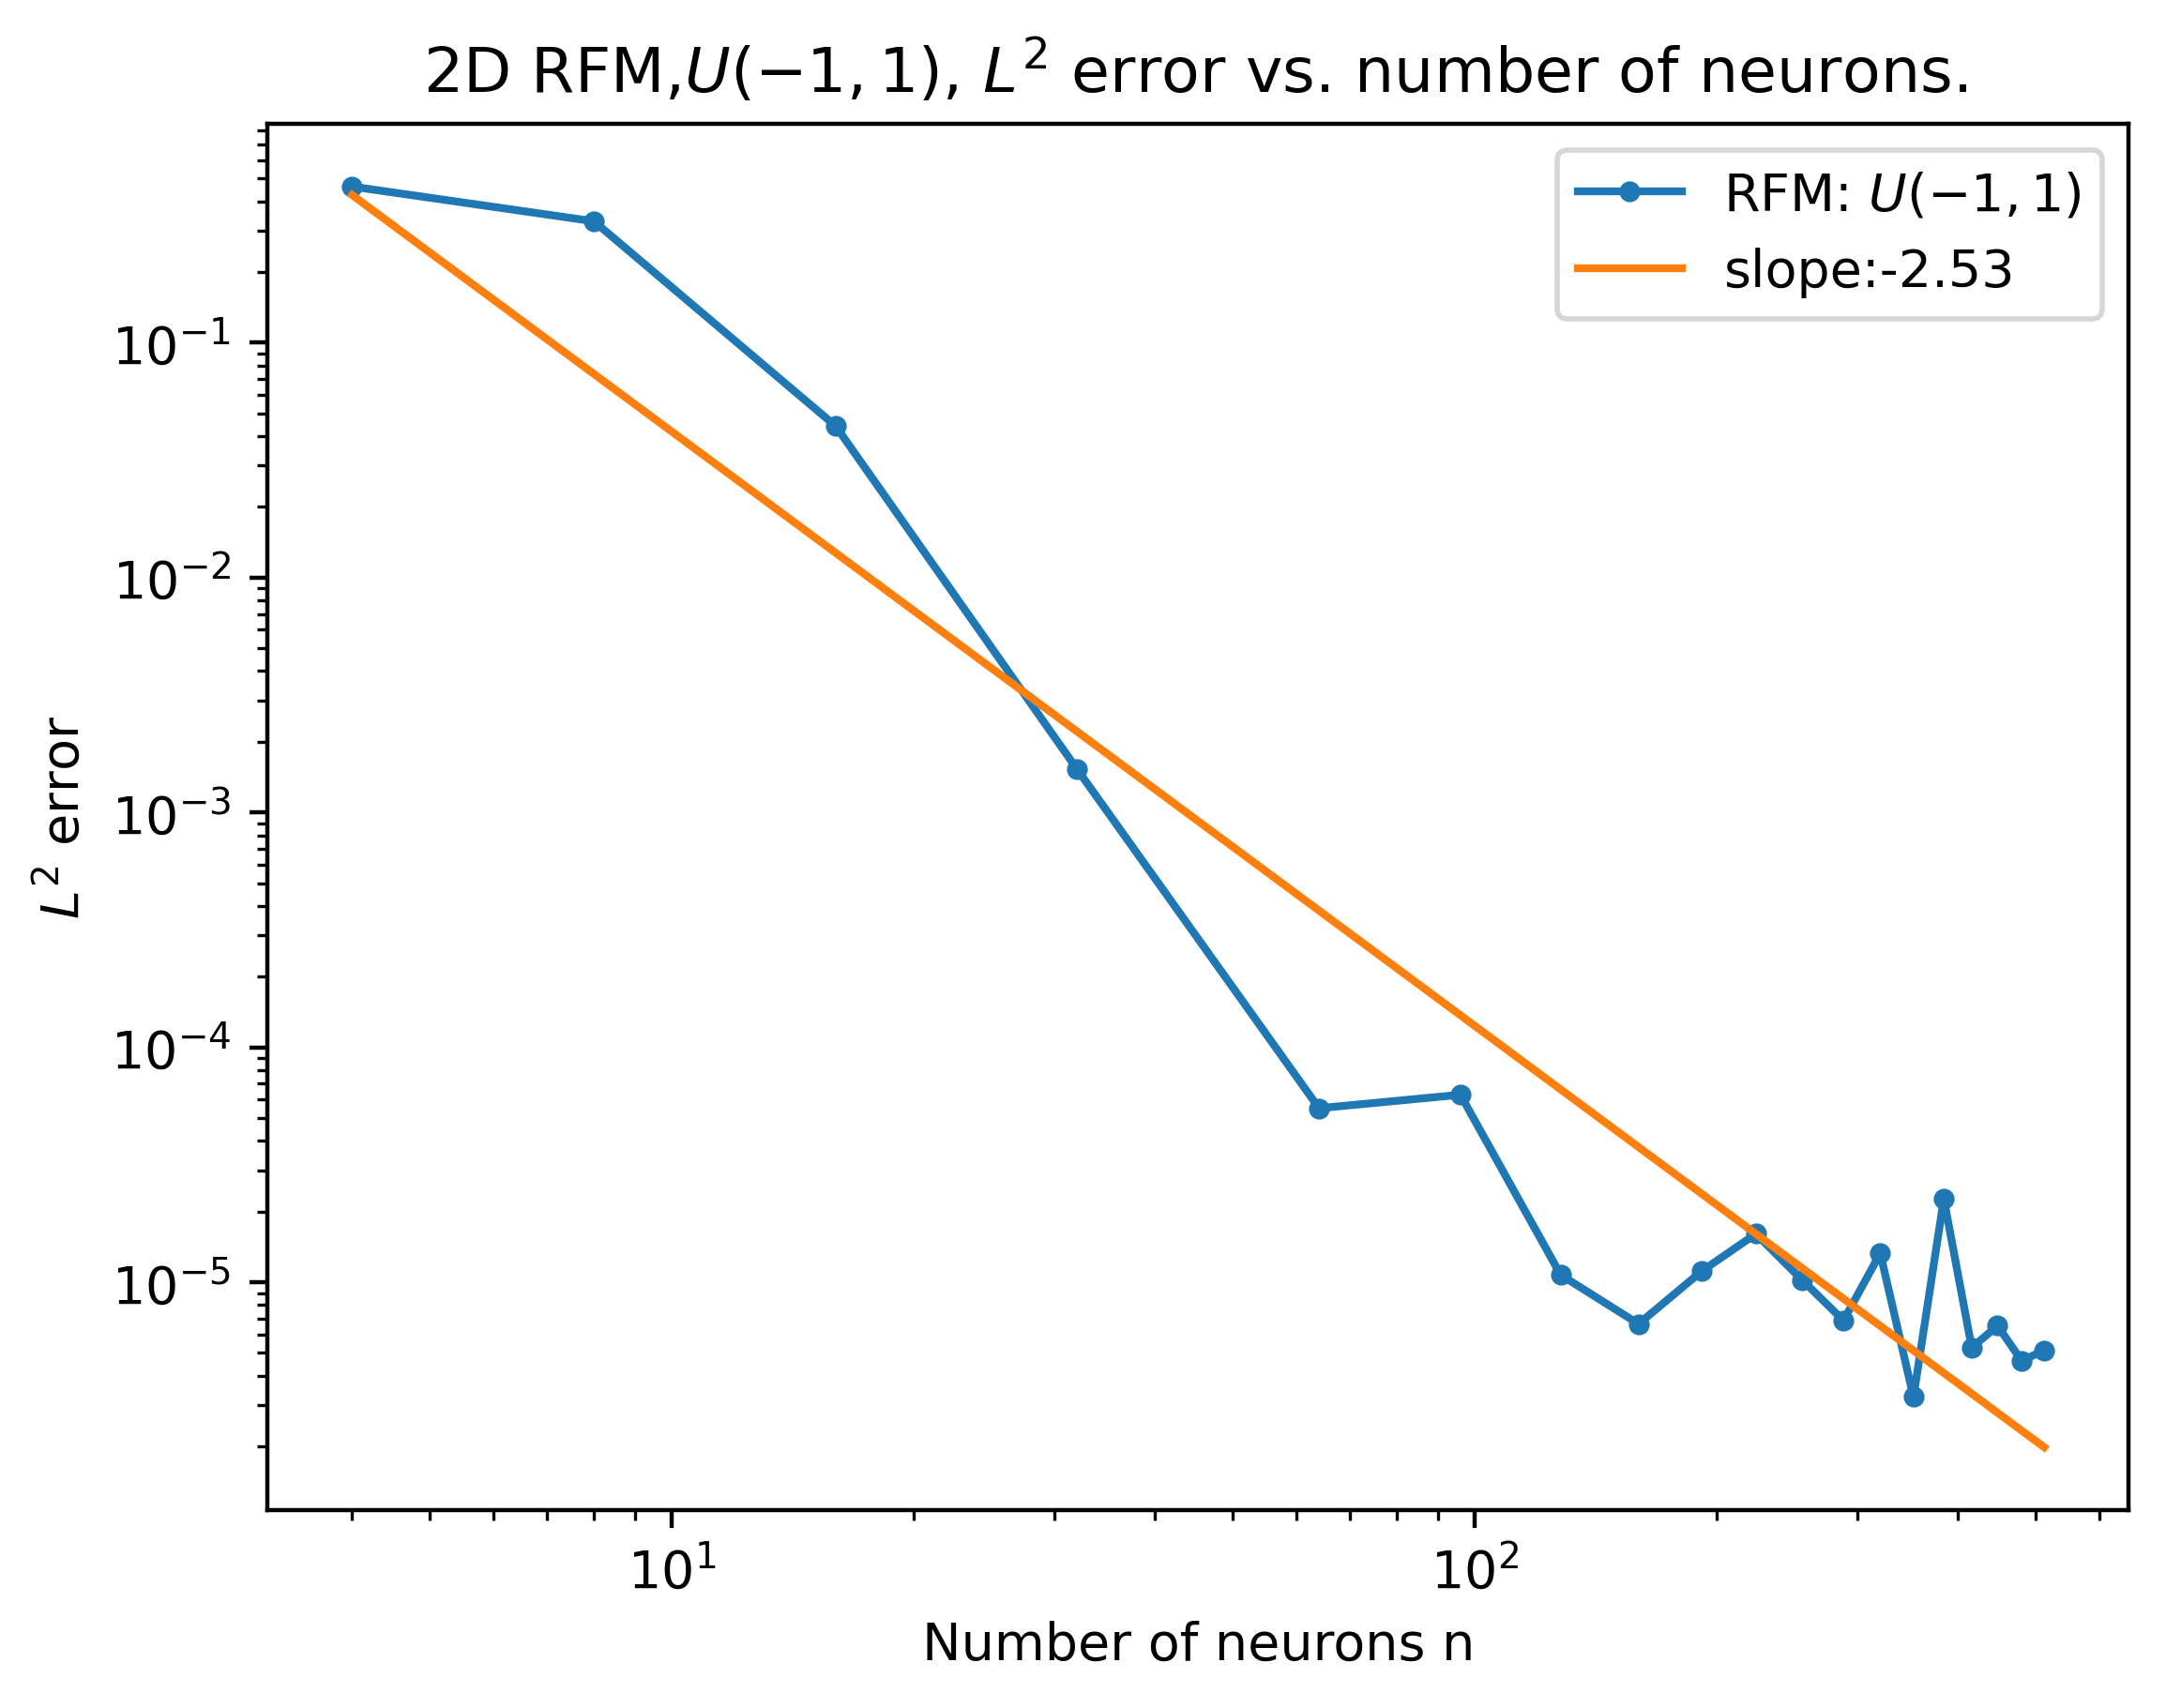

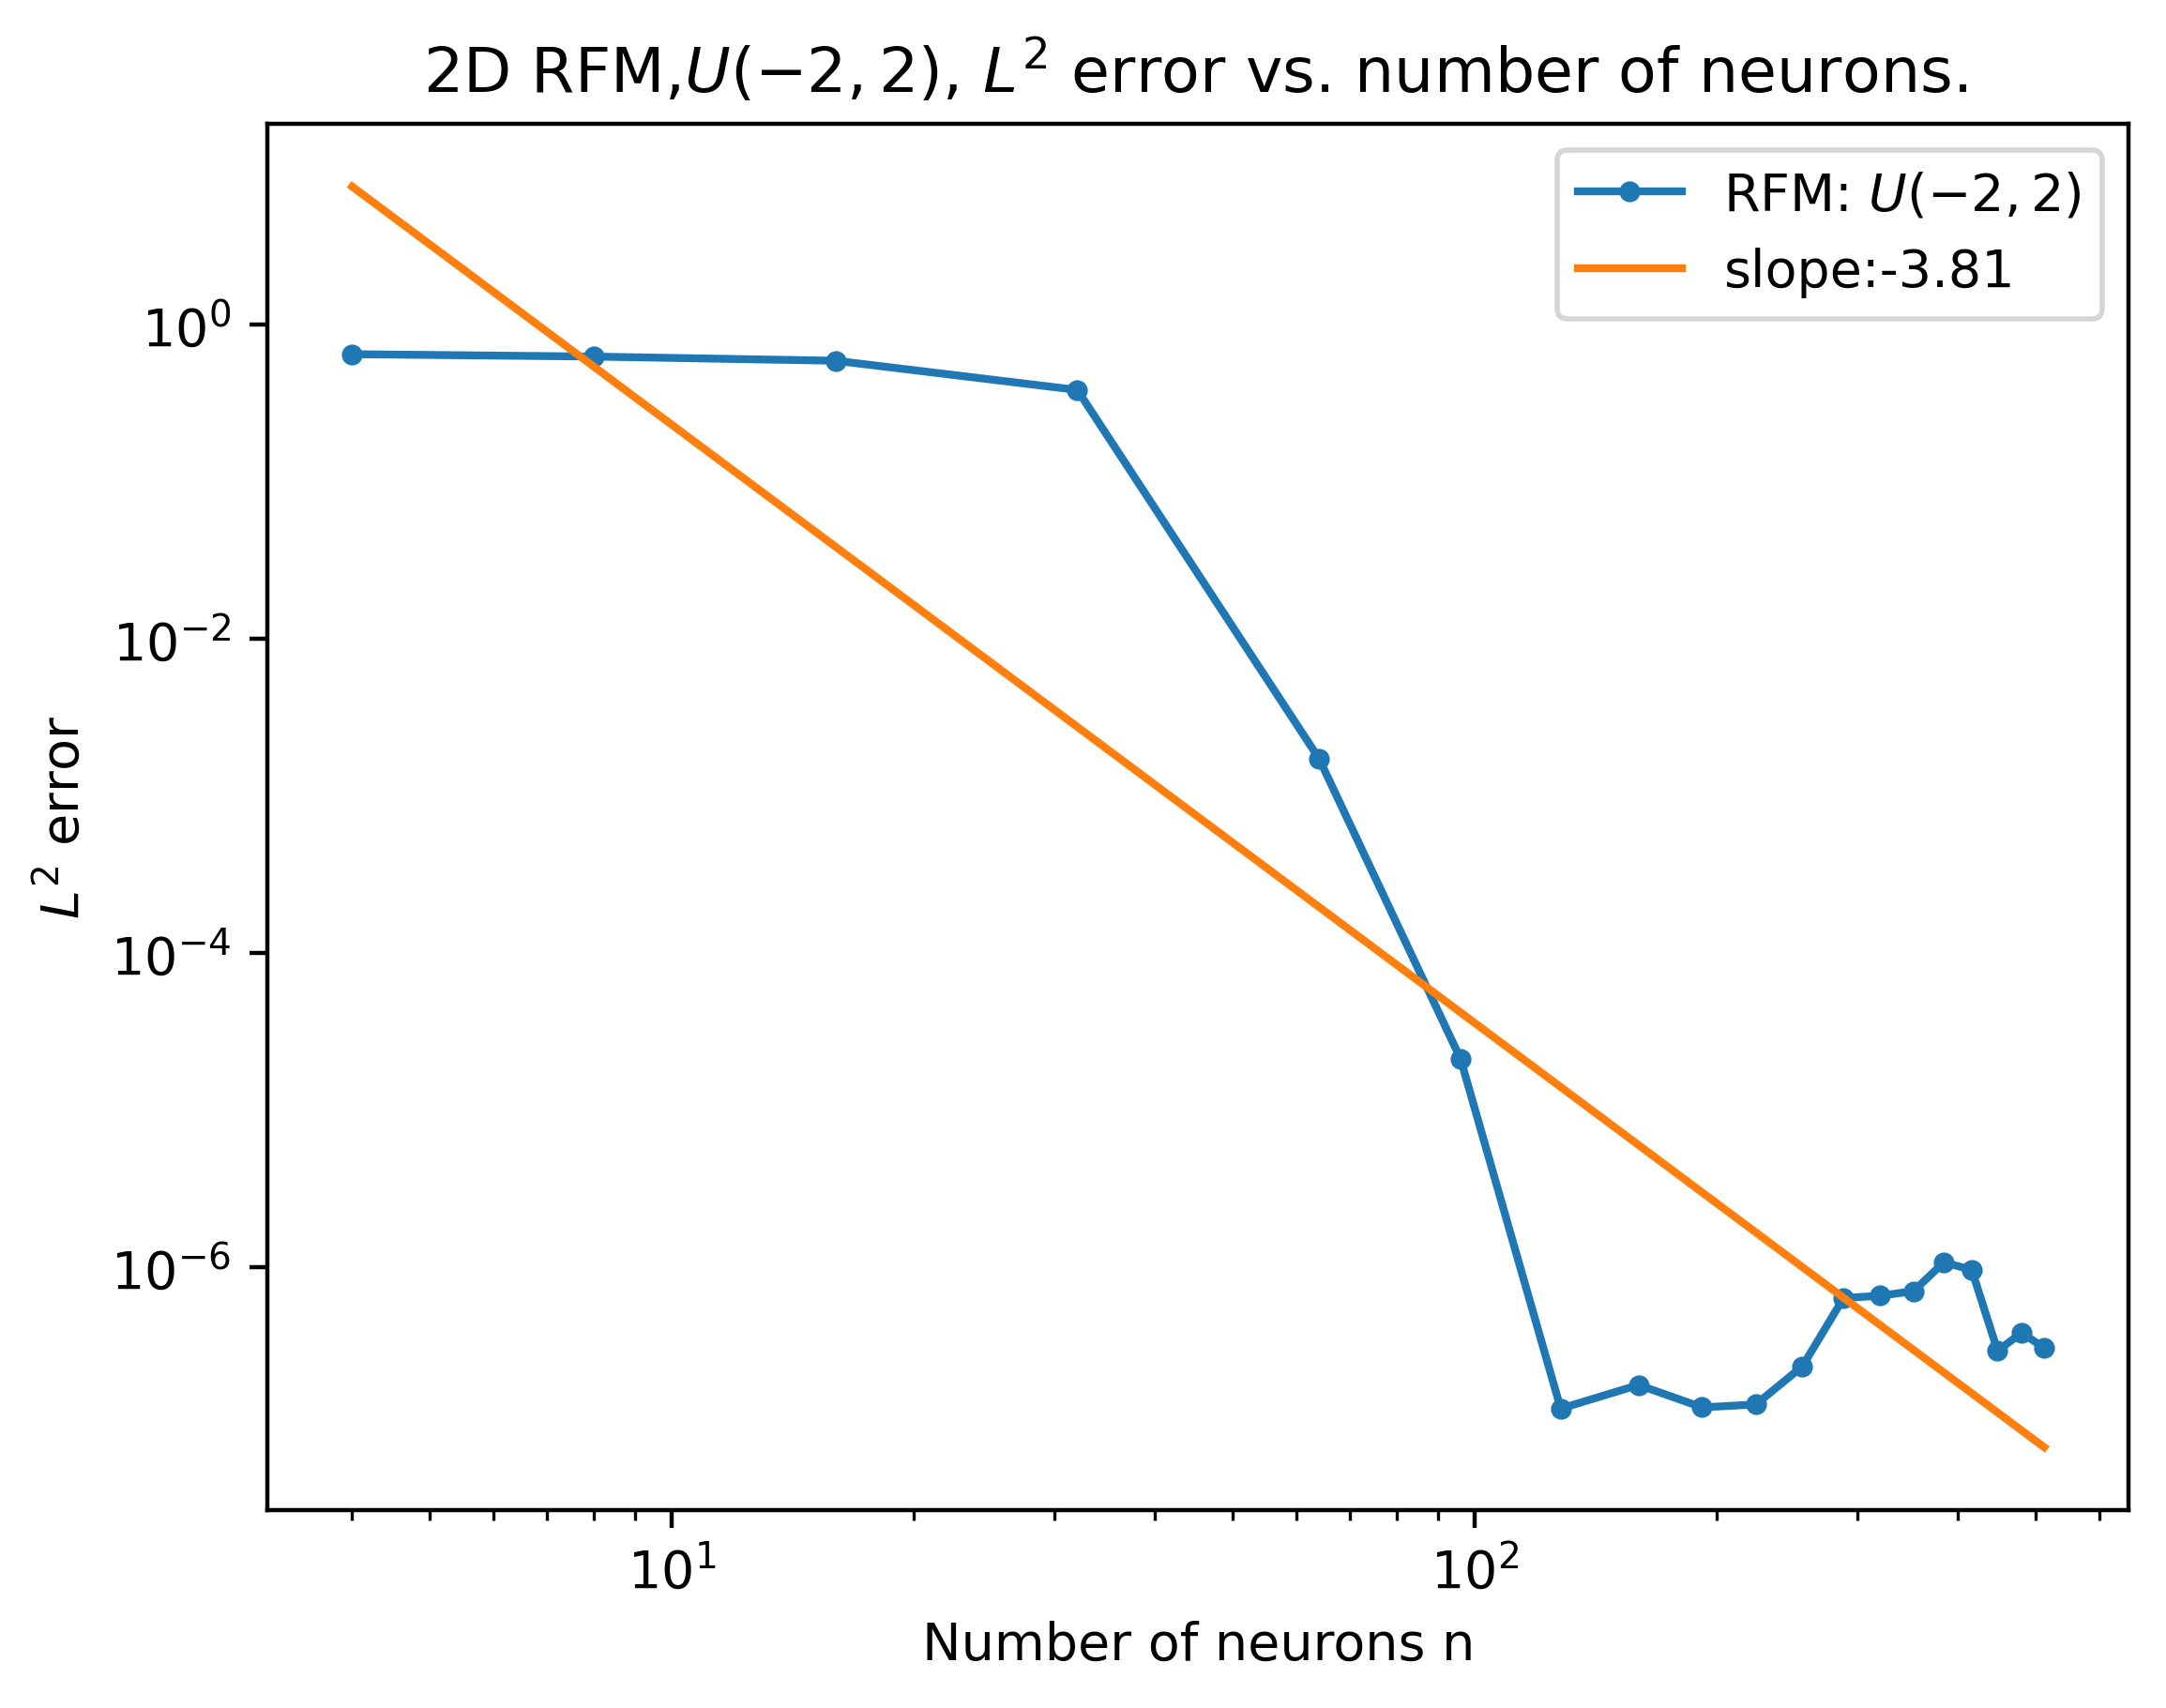

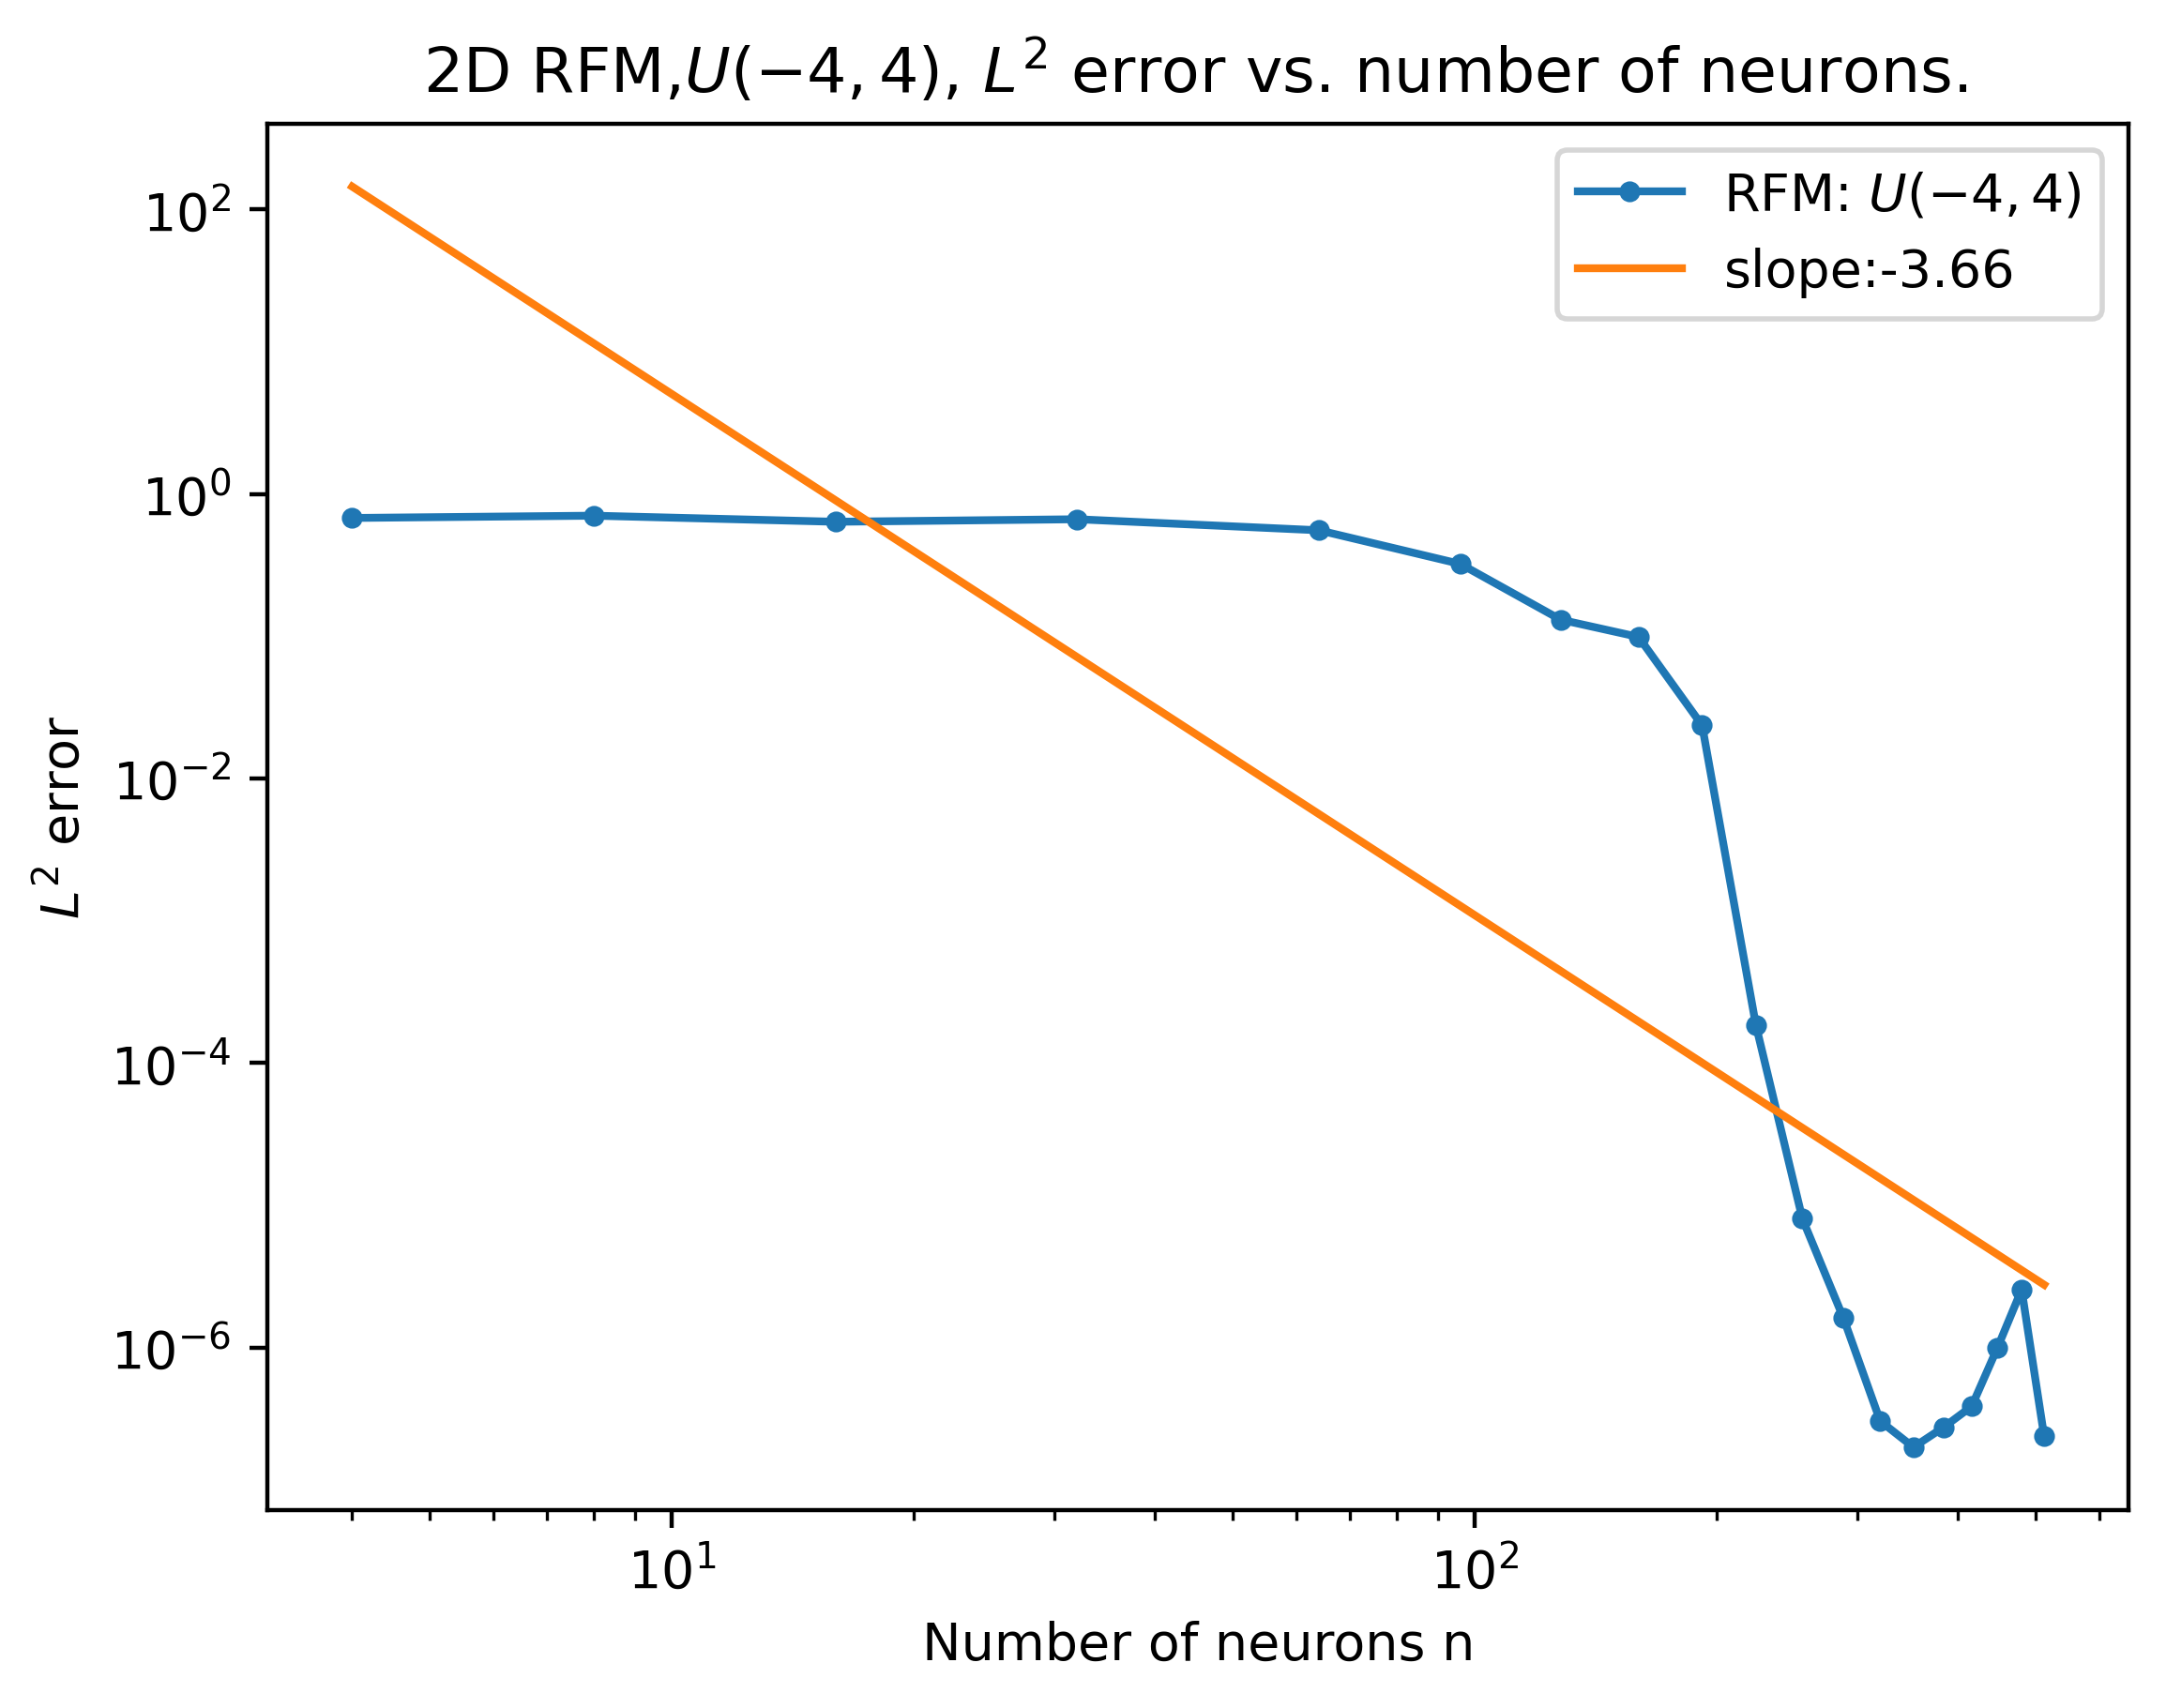

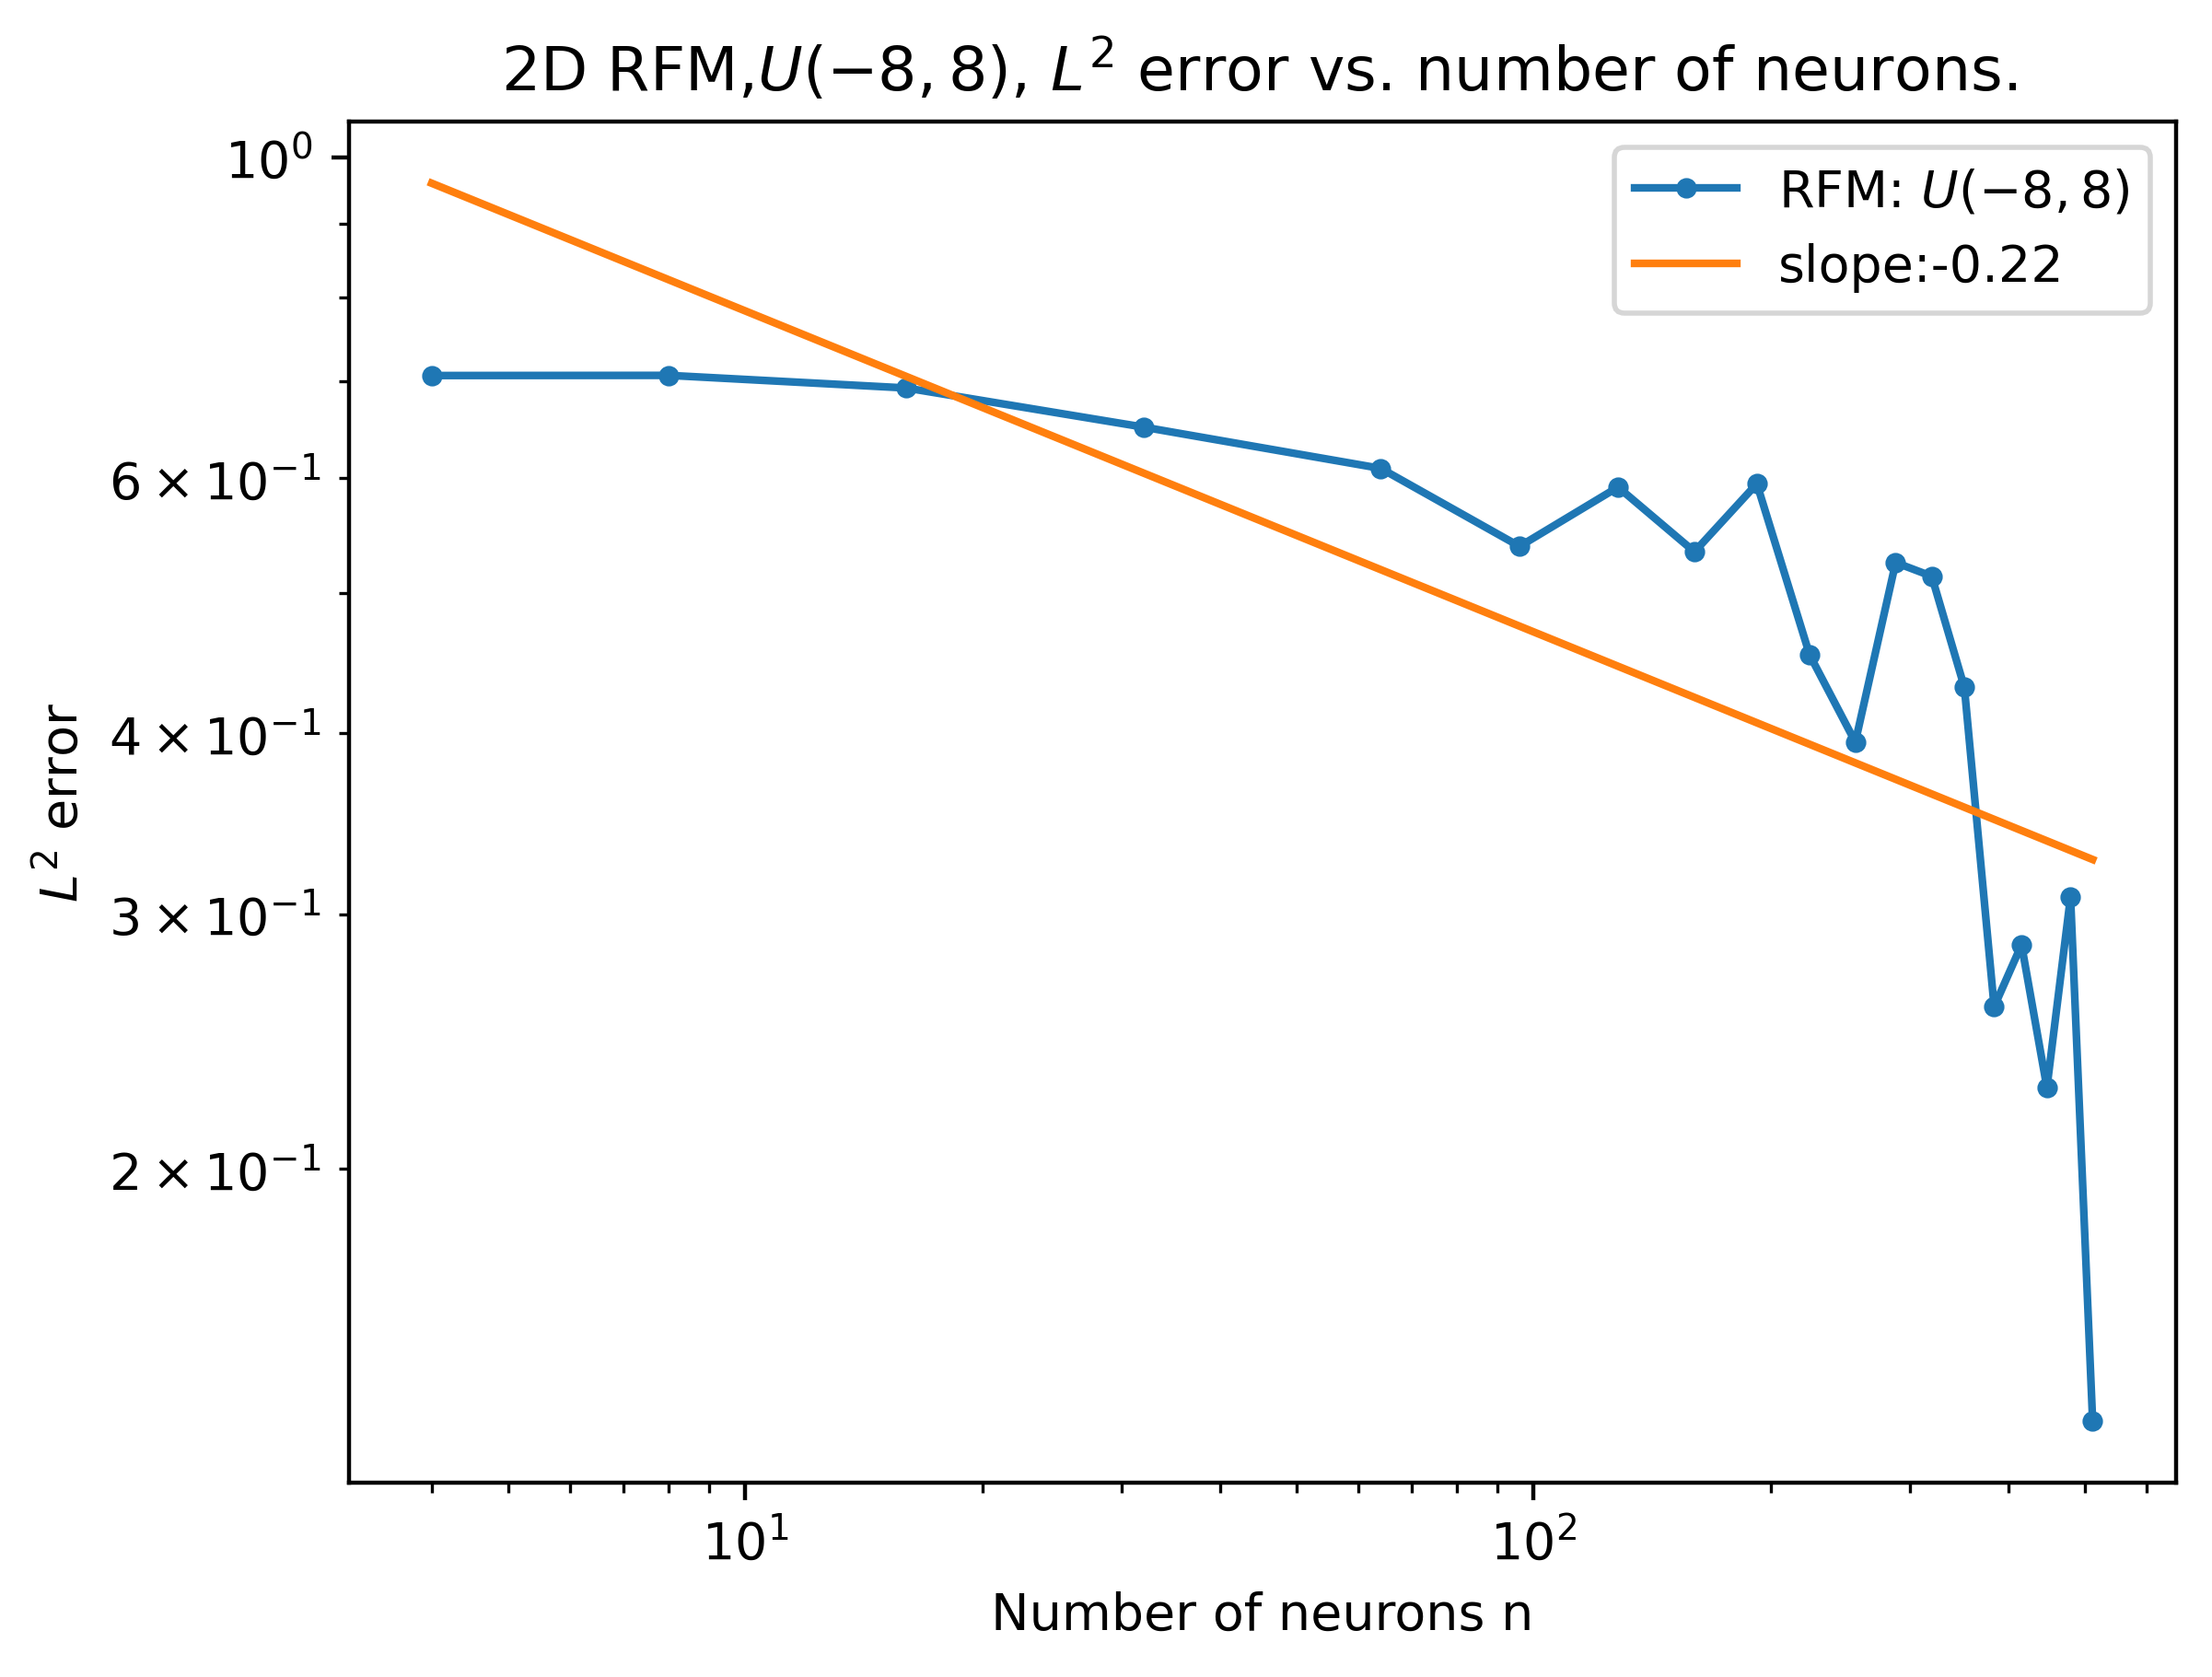

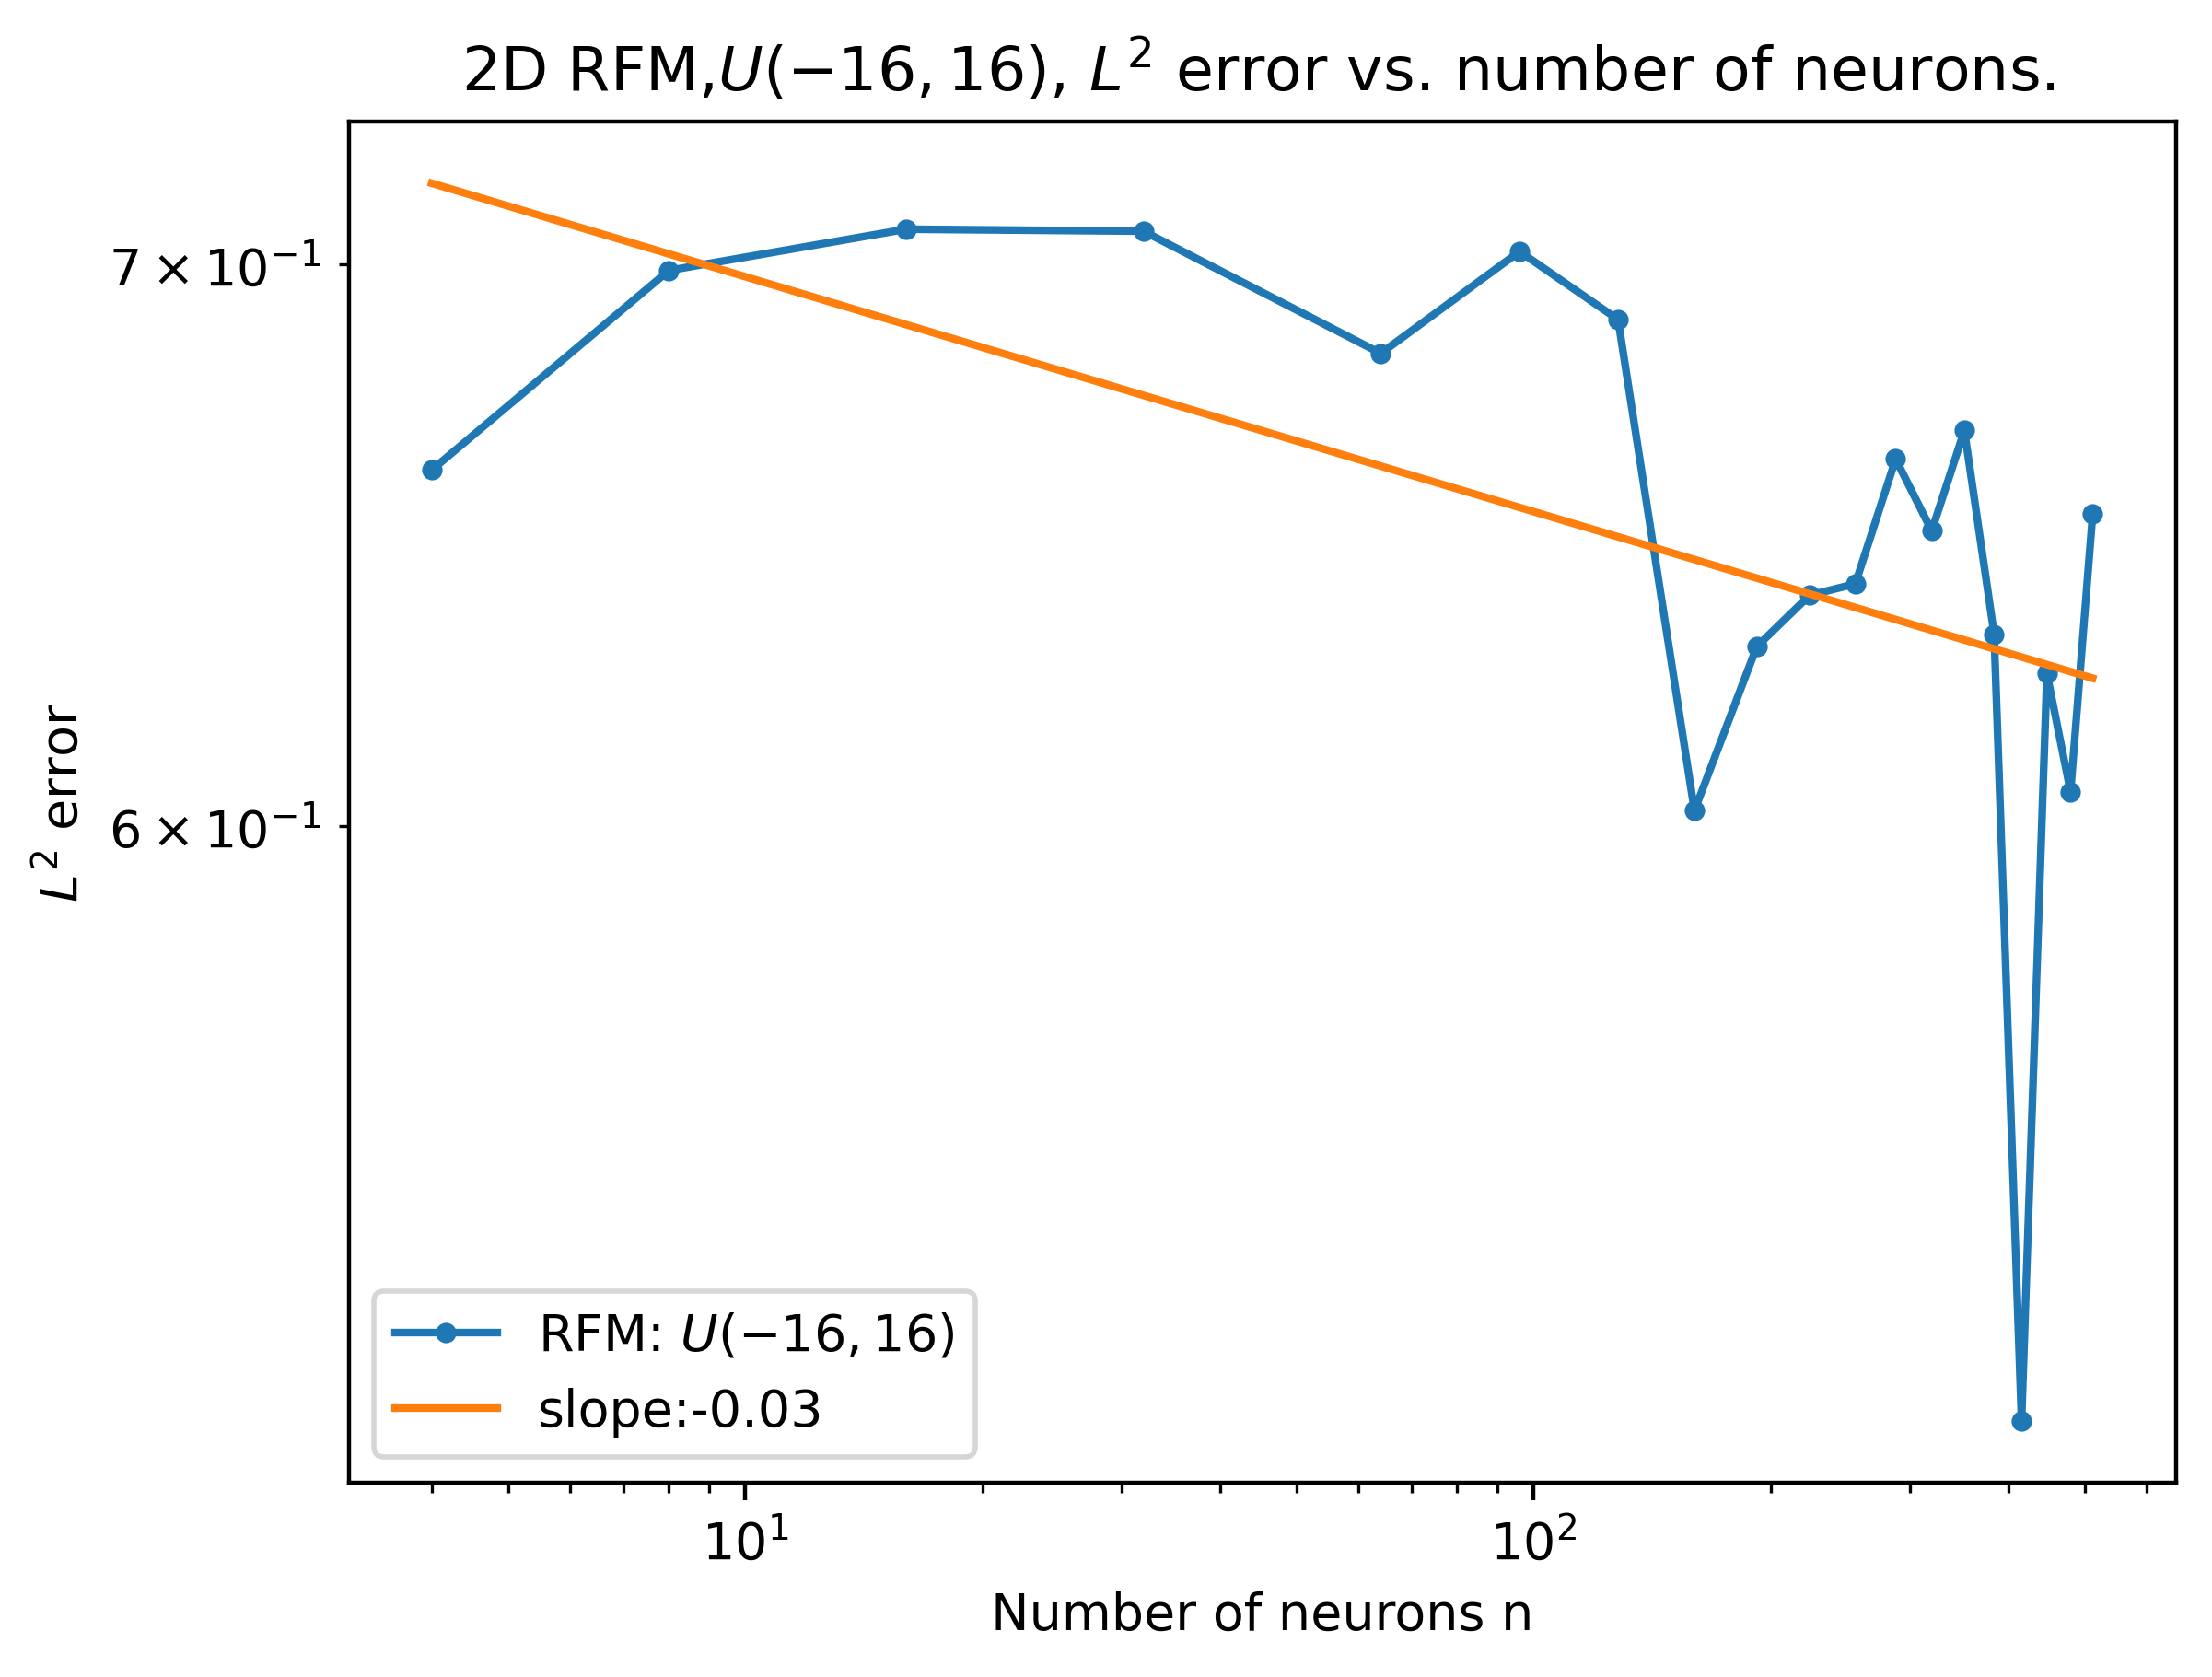

In [176]:
def target(x): 
    return torch.exp(-pi*torch.sum(x**2, dim = 1, keepdim = True)) # +  0.2 * torch.sin(4 * pi * x) 

weights, integration_points = PiecewiseGQ2D_weights_points(Nx = 50, order = 3, l_point = (-1,-1), r_point = (1,1)) 
save = False 
for R_m in [1,2,4,8,16]: #  
    mean_err_l2_list = [] 
    exponent = 8 

    neuron_num_arr1 = np.array([2**i for i in range(2,6)]) 
    neuron_num_arr2 = np.arange(2**6, 512 +1, 32)
    neuron_num_arr = np.append(neuron_num_arr1,neuron_num_arr2) 

    for n in neuron_num_arr : 
        trial_num = 10  
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_cosine(2, n, 1).to(device) 
            # my_model = set_linear_layer_to_fixed_weights(my_model) 
            # mu = 0 
            # sigma = (0.5/pi)**0.5  
            my_model = initialize_w_b_uniform(my_model,R_m) 
            sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct")
            my_model.fc2.weight.data[0,:] = sol[:]


            with torch.no_grad():
                nn_func_values = my_model(integration_points)
            target_values = target(integration_points) 

            diff_sqrd = (nn_func_values - target_values)**2
            err_l2 = ( weights.t() @ diff_sqrd )**0.5 
            err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("ave_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
    legend1 = "RFM: $U(-{}, {})$".format(R_m,R_m)
    title = "2D RFM,$U(-{}, {})$, $L^2$ error vs. number of neurons. ".format(R_m,R_m) 
    plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title) 

In [ ]:
##

## 3D Monte-Carlo sampling 


In [16]:
def target(x): 
    return torch.exp(-pi*torch.sum(x**2, dim = 1, keepdim = True) ) # +  0.2 * torch.sin(4 * pi * x) 

err_l2_list = [] 
neuron_arr = torch.arange(1,2000,100) 
for n in neuron_arr: 

    my_model = model_cosine(3, n, 1).to(device) 
    my_model = set_linear_layer_to_fixed_weights(my_model) 
    mu = 0 
    sigma = (0.5/pi)**0.5
    my_model = initialize_normal(my_model,mu,sigma) 

    # x_coord = torch.linspace(-1,1,1000).reshape(-1,1).to(device) 
    # nn_func_values = my_model(x_coord).detach()
    # target_values = target(x_coord) 

    # plt.plot(x_coord,nn_func_values, label = 'nn approximation')
    # plt.plot(x_coord,target_values, label = 'target')  
    # plt.legend() 
    # plt.show() 
    weights, integration_points = PiecewiseGQ3D_weights_points(26,3,l_point = (-1,-1,-1), r_point = (1,1,1))
    with torch.no_grad():
        nn_func_values = my_model(integration_points) 
    target_values = target(integration_points) 
    diff_sqrd = (nn_func_values - target_values)**2 
    err_l2 = ( weights.t() @ diff_sqrd )**0.5 
    # err_l2 = torch.sqrt(2 * torch.mean((nn_func_values - target_values)**2)) 
    
    print("L2 error: ",err_l2) 
    err_l2_list.append(err_l2) 


L2 error:  tensor([[2.0587]])
L2 error:  tensor([[0.1874]])
L2 error:  tensor([[0.1342]])
L2 error:  tensor([[0.1342]])
L2 error:  tensor([[0.1067]])
L2 error:  tensor([[0.1127]])
L2 error:  tensor([[0.0871]])
L2 error:  tensor([[0.0757]])
L2 error:  tensor([[0.0704]])
L2 error:  tensor([[0.0606]])
L2 error:  tensor([[0.0535]])
L2 error:  tensor([[0.0530]])
L2 error:  tensor([[0.0561]])
L2 error:  tensor([[0.0595]])
L2 error:  tensor([[0.0476]])
L2 error:  tensor([[0.0447]])
L2 error:  tensor([[0.0436]])
L2 error:  tensor([[0.0522]])
L2 error:  tensor([[0.0362]])
L2 error:  tensor([[0.0396]])


/Applications/anaconda3/lib/python3.9/site-packages/numpy/core/shape_base.py:65: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  ary = asanyarray(ary)
/Applications/anaconda3/lib/python3.9/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


torch.Size([1, 20])
torch.Size([20])


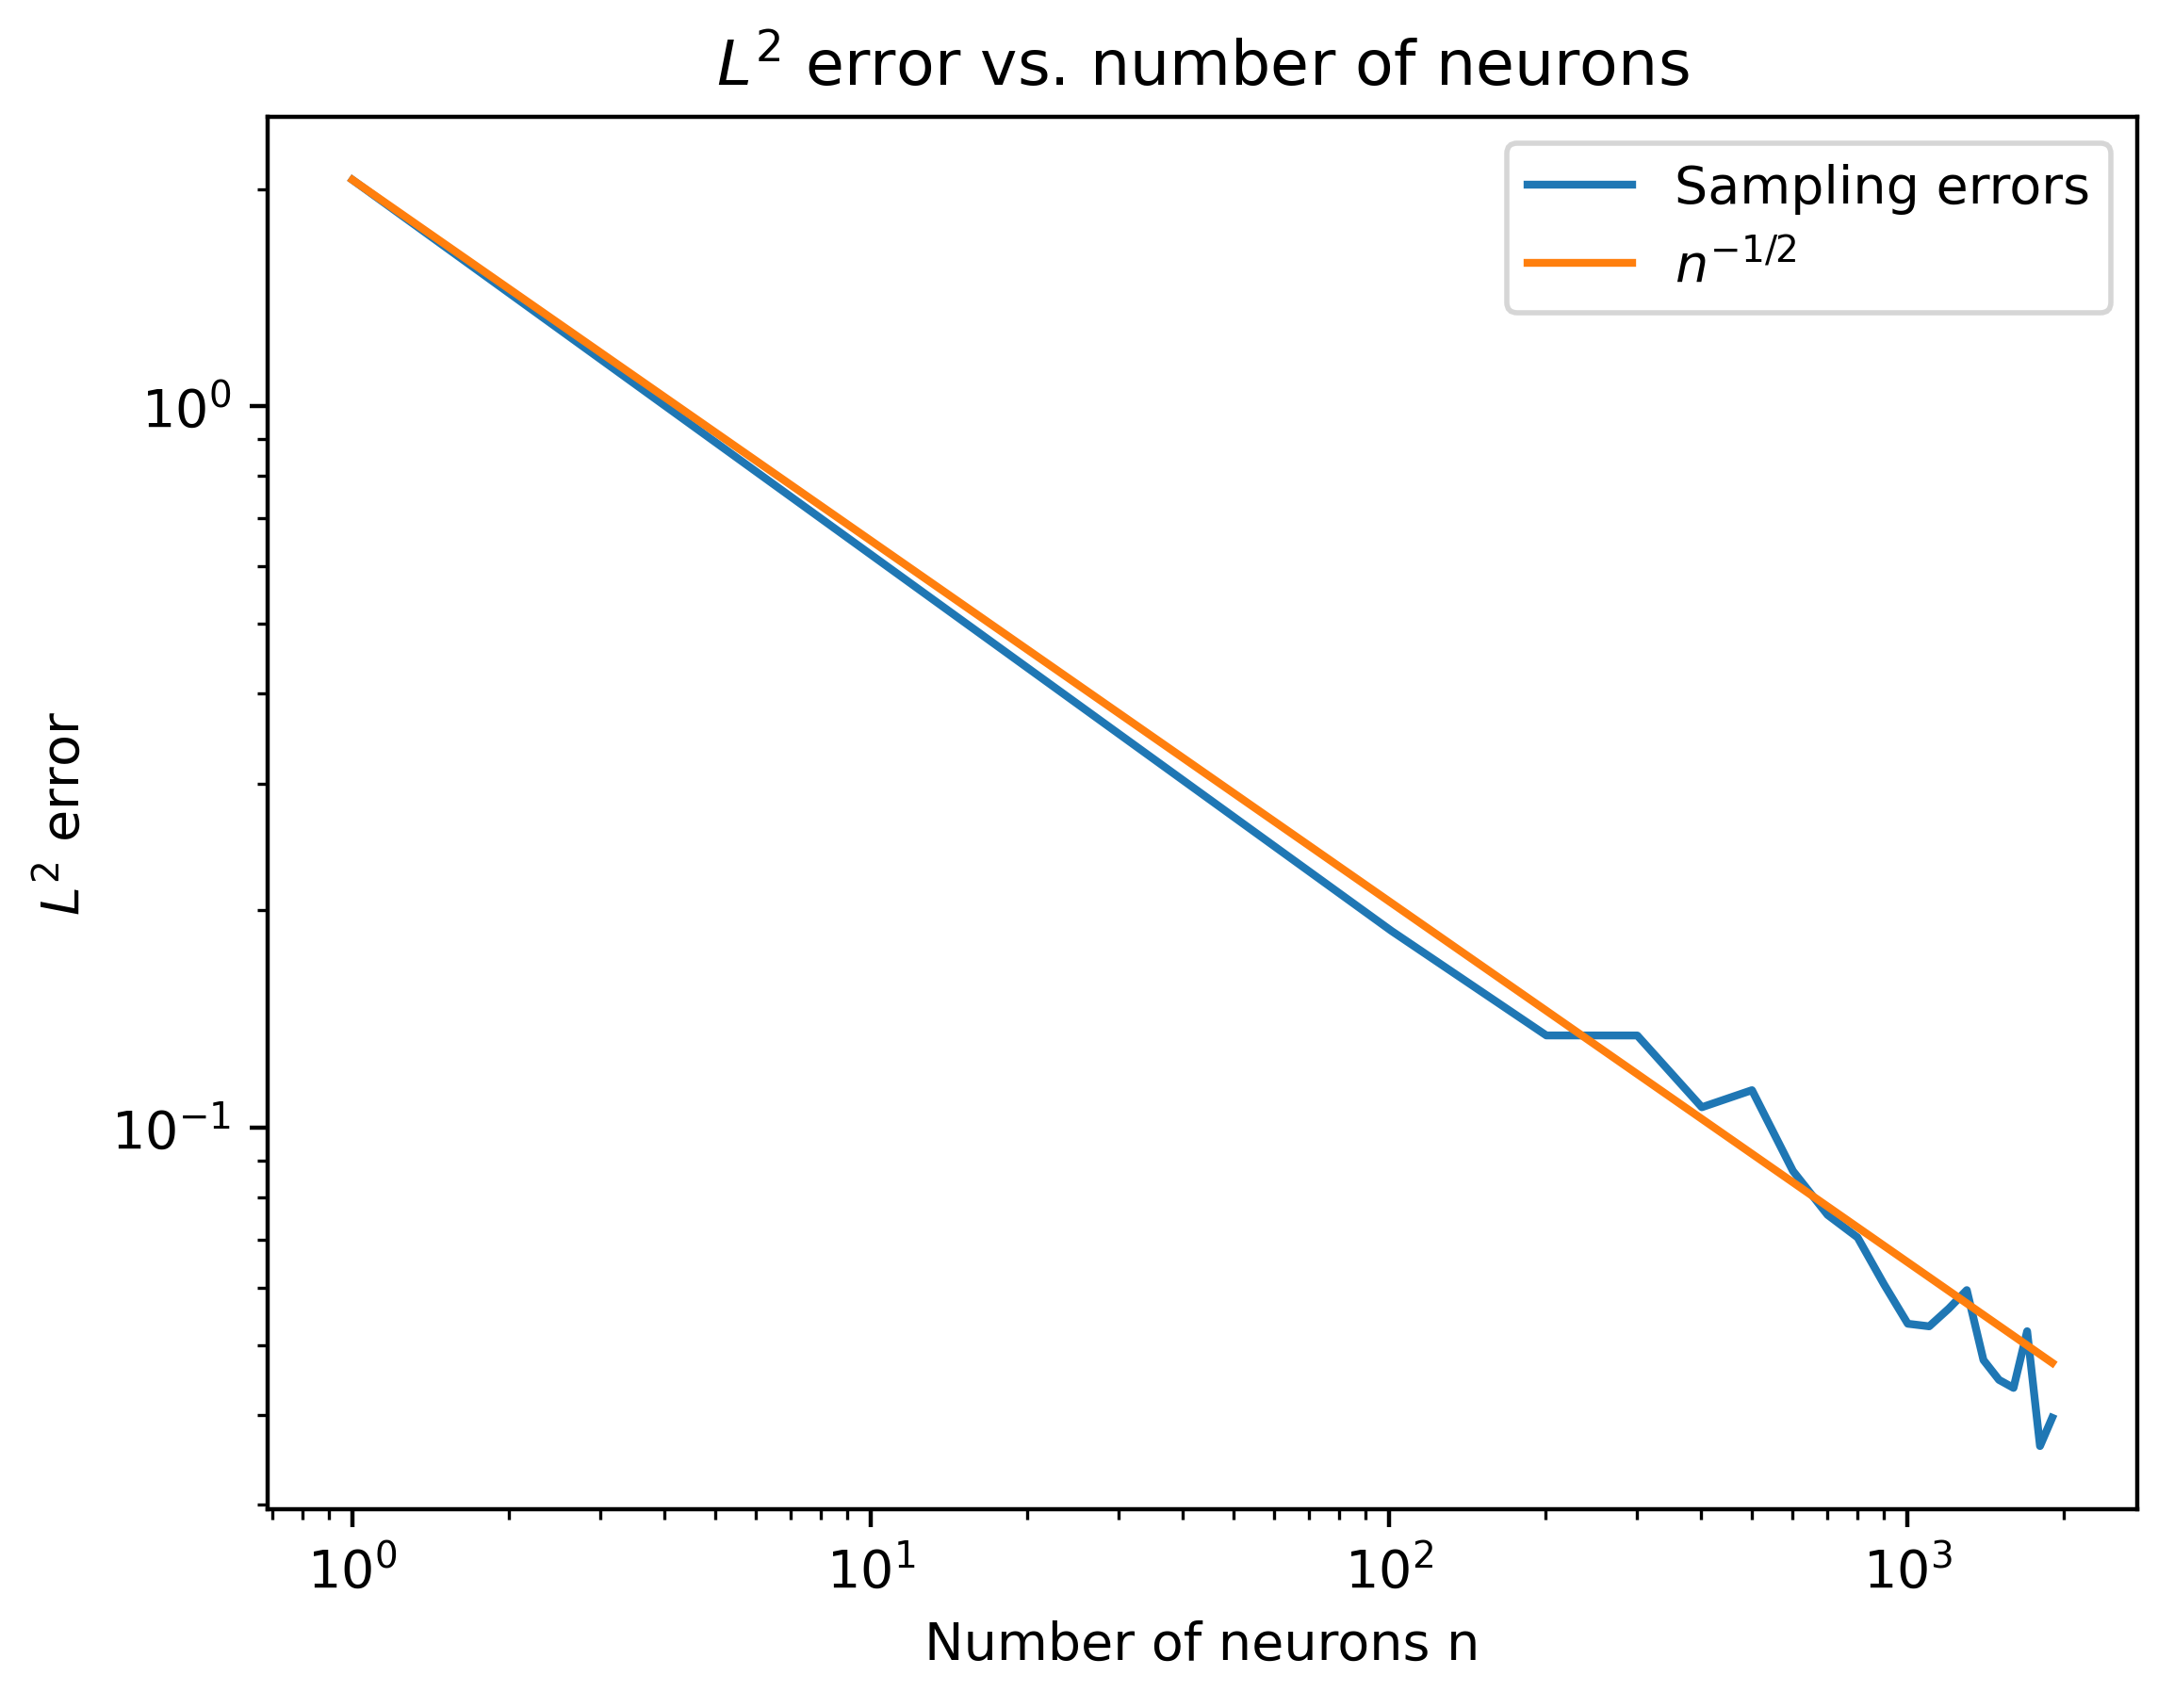

In [23]:
plt.figure(dpi = 400)
plt.plot(neuron_arr, err_l2_list, label = "Sampling errors") 
ref_line = err_l2_list[0] * torch.tensor([1/(n**0.5) for n in neuron_arr])

print(ref_line.size())
print(neuron_arr.size()) 

plt.plot(neuron_arr,ref_line.squeeze(), label = "$n^{-1/2}$") 
plt.yscale('log') 
plt.xscale('log') 
plt.ylabel("$L^2$ error") 
plt.xlabel("Number of neurons n") 
plt.title("$L^2$ error vs. number of neurons") 
plt.legend() 
plt.show() 